In [15]:
import scanpy as sc

In [16]:
import pandas as pd

In [17]:
print(sc.__version__)

1.10.4


In [18]:
#import velocyto as vcy

In [19]:
#print(vcy.__version__)

In [20]:
#.libPaths()

In [21]:
#library(velocyto.R)

In [22]:
#packageVersion("velocyto.R")

In [23]:
# https://pklab.med.harvard.edu/velocyto/notebooks/R/chromaffin2.nb.html

In [24]:
#library(Seurat)

In [25]:
# multimodal omics data

In [26]:
import muon as mu

In [27]:
# multi omics format for storing modalities like rna, atac
mu.read_h5mu("/home/rstudio/run070/run070-nsclc-3.h5mu")

MuData object with n_obs × n_vars = 5755 × 28948
  var:	'Raw_Reads', 'Raw_Molecules', 'Raw_Seq_Depth', 'RSEC_Adjusted_Molecules', 'RSEC_Adjusted_Reads_non-singleton', 'RSEC_Adjusted_Molecules_non-singleton'
  1 modality
    rna:	5755 x 28948
      obs:	'Cell_Type_Experimental', 'Total_VDJ_Read_Count', 'Total_VDJ_Molecule_Count', 'TCR_Alpha_Gamma_V_gene_Dominant', 'TCR_Alpha_Gamma_J_gene_Dominant', 'TCR_Alpha_Gamma_C_gene_Dominant', 'TCR_Alpha_Gamma_CDR3_Nucleotide_Dominant', 'TCR_Alpha_Gamma_CDR3_Translation_Dominant', 'TCR_Alpha_Gamma_Read_Count', 'TCR_Alpha_Gamma_Molecule_Count', 'TCR_Beta_Delta_V_gene_Dominant', 'TCR_Beta_Delta_D_gene_Dominant', 'TCR_Beta_Delta_J_gene_Dominant', 'TCR_Beta_Delta_C_gene_Dominant', 'TCR_Beta_Delta_CDR3_Nucleotide_Dominant', 'TCR_Beta_Delta_CDR3_Translation_Dominant', 'TCR_Beta_Delta_Read_Count', 'TCR_Beta_Delta_Molecule_Count', 'TCR_Paired_Chains', 'High_Quality_Cell'
      var:	'Raw_Reads', 'Raw_Molecules', 'Raw_Seq_Depth', 'RSEC_Adjusted_Molecules', 'RSEC_Adjusted_Reads_non-singleton', 'RSEC_Adjusted_Molecules_non-singleton'
      uns:	'Pipeline_Inputs', 'Pipeline_Metrics'
      obsm:	'X_tsne', 'X_umap'

In [28]:
patient_data070 = mu.read_h5mu("/home/rstudio/run070/run070-nsclc-3.h5mu")

## Exploratory analysis

In [29]:
# Pipeline_Metrics - summary statistics
patient_data070.mod['rna'].uns['Pipeline_Metrics']

{'Alignment_Categories':                                                Total_CellLabel_UMI_Reads  \
 Library                                                                    
 Pr416_Pat3TCR_MKDL240011295-1A_22JYTMLT4_L4_1                   60908082   
 Pr416_Pat3WTA_MKDL240011294-1A_22JL3VLT4_L3_1                   36215077   
 Pr416_Pat3WTA_MKDL240011294-1A_22JYTMLT4_L4_1                  202964593   
 Pr416_Pat3WTA_MKDL240011294-1A_22MKKNLT3_L6_1                    9100962   
 Combined_stats                                                 309188714   
 
                                                Annotated_Transcriptome_Pct  \
 Library                                                                      
 Pr416_Pat3TCR_MKDL240011295-1A_22JYTMLT4_L4_1                         0.12   
 Pr416_Pat3WTA_MKDL240011294-1A_22JL3VLT4_L3_1                        54.80   
 Pr416_Pat3WTA_MKDL240011294-1A_22JYTMLT4_L4_1                        54.38   
 Pr416_Pat3WTA_MKDL240011294-1A_22MKKNLT

In [30]:
# - RSEC (Recursive Substitution Error Correction) - molecule count correction
## RSEC method used during sequencing error correction  - important in counting unique mRNA molecules accurately (used in UMI based scRNA seq)

In [31]:
# Cell_Type_Experimental

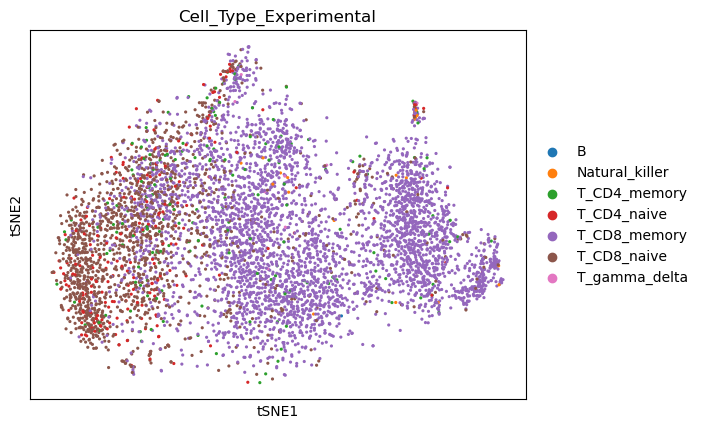

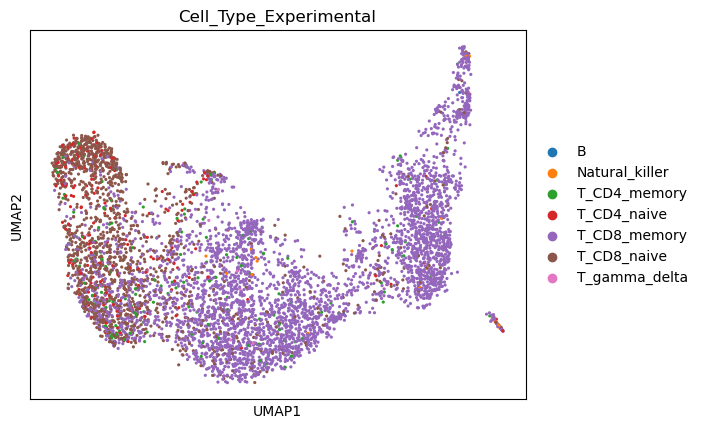

In [32]:
sc.pl.tsne(patient_data070.mod['rna'], color='Cell_Type_Experimental')
sc.pl.umap(patient_data070.mod['rna'], color='Cell_Type_Experimental')

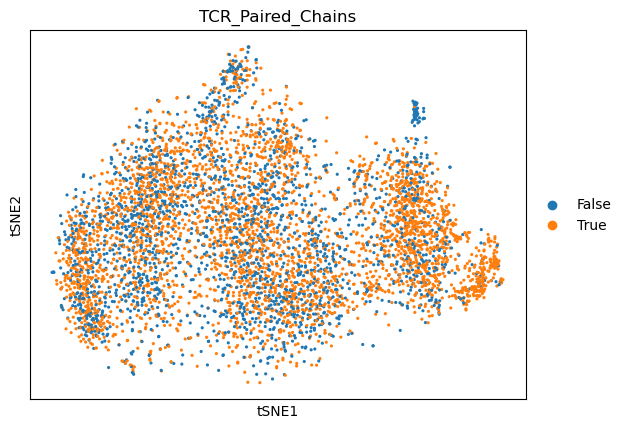

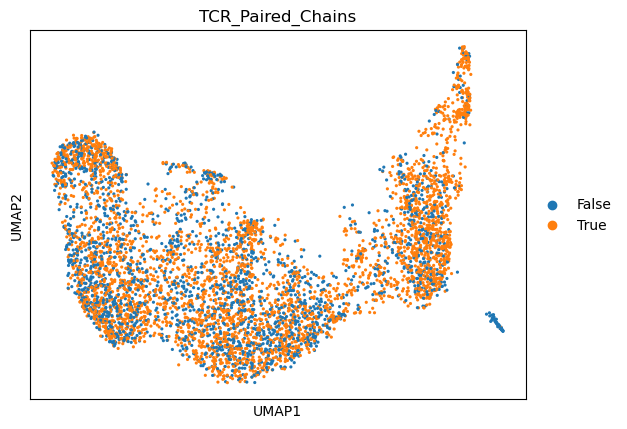

In [33]:
sc.pl.tsne(patient_data070.mod['rna'], color='TCR_Paired_Chains')
sc.pl.umap(patient_data070.mod['rna'], color='TCR_Paired_Chains')

In [34]:
# alpha beta diversity

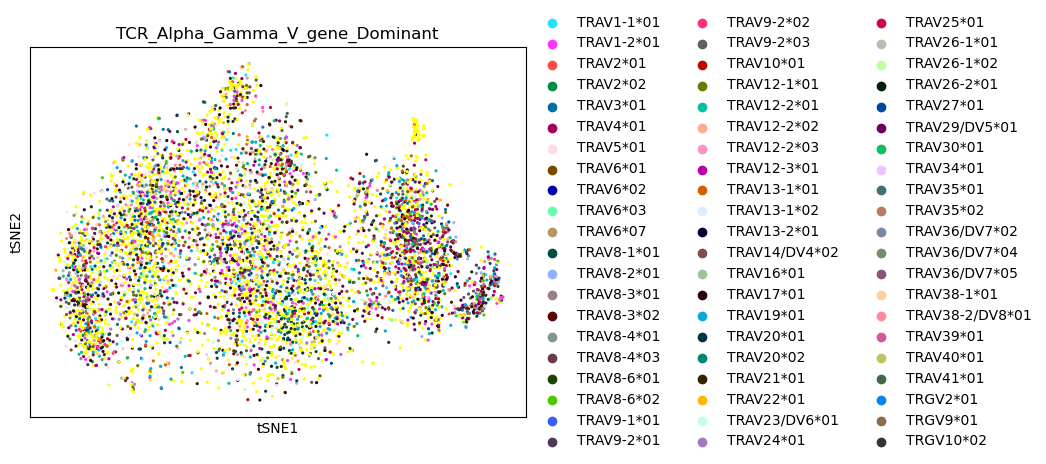

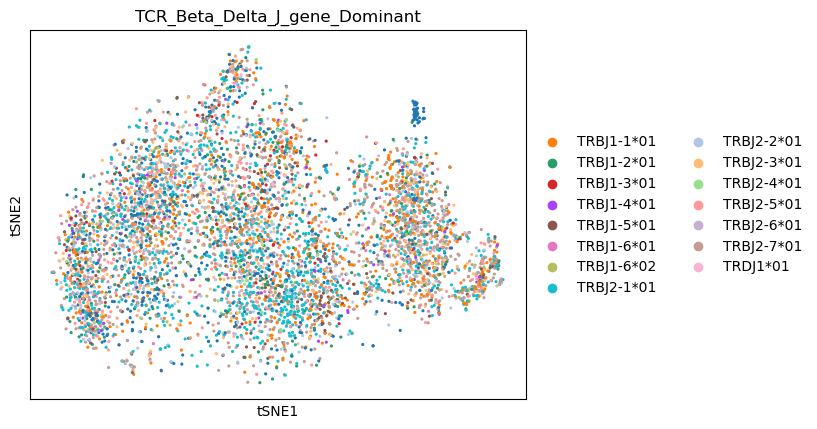

In [35]:
sc.pl.tsne(patient_data070.mod['rna'], color='TCR_Alpha_Gamma_V_gene_Dominant')
sc.pl.tsne(patient_data070.mod['rna'], color='TCR_Beta_Delta_J_gene_Dominant')
# identify clonal lineages or immune signatures associated with disease state

In [36]:
# Cool way of visualizing
with mu.set_options(display_style = "html", display_html_expand = 0b000):
    display(patient_data070)

Using custom muon options in the new context...


rna:Cell_Type_Experimental,category,"T_CD8_memory,T_CD8_naive,T_CD8_memory,T_CD8_memory..."
rna:Total_VDJ_Read_Count,int64,"25473,1846,1170,15606,5071,4516,8921,6125,14902,79..."
rna:Total_VDJ_Molecule_Count,int64,"94,7,4,22,15,10,21,11,28,7,3,12,4,5,1,9,9,6,15,0,1..."
rna:TCR_Alpha_Gamma_V_gene_Dominant,category,"TRAV4*01,,TRAV14/DV4*02,TRAV3*01,TRAV36/DV7*04,,TR..."
rna:TCR_Alpha_Gamma_J_gene_Dominant,category,"TRAJ38*01,,TRAJ17*01,TRAJ50*01,TRAJ57*01,,TRAJ16*0..."
rna:TCR_Alpha_Gamma_C_gene_Dominant,category,"TRAC,,TRAC,TRAC,TRAC,,TRAC,TRAC,TRAC,,TRAC,,,,TRAC..."
rna:TCR_Alpha_Gamma_CDR3_Nucleotide_Dominant,category,"CTCGTGGGTACGGCTGGCAACAACCGTAAGCTGATT,,GCAATGGAAGCT..."
rna:TCR_Alpha_Gamma_CDR3_Translation_Dominant,category,"LVGTAGNNRKLI,,AMEAAGNKLT,AVRAGETSYDKVI,HQGGSEKLV,,..."
rna:TCR_Alpha_Gamma_Read_Count,int64,"13739,0,512,101,2189,0,3659,1034,4088,0,833,0,0,0,..."
rna:TCR_Alpha_Gamma_Molecule_Count,int64,"27,0,2,1,6,0,5,3,10,0,1,0,0,0,1,5,0,0,2,0,0,3,2,3,..."
rna:TCR_Beta_Delta_V_gene_Dominant,category,"TRBV4-1*01,TRBV4-2*01,TRBV19*01,TRBV12-4*01,TRBV4-..."


Returning to the previously defined mudata options: {'display_style': 'text', 'display_html_expand': 2}
Returning to the previously defined muon options: {}


## Processing

In [37]:
rna = patient_data070.mod['rna']
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
rna.var["mt"] = rna.var_names.str.startswith("MT-")
# ribosomal genes
rna.var["ribo"] = rna.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
rna.var["hb"] = rna.var_names.str.contains("^HB[^(P)]")

- High mitochondrial content - dying or stressed cells.
- High ribosomal gene exp - proliferative status.
- Hemoglobin genes - contamination by red blood cells.

In [38]:
sc.pp.calculate_qc_metrics(
    rna, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

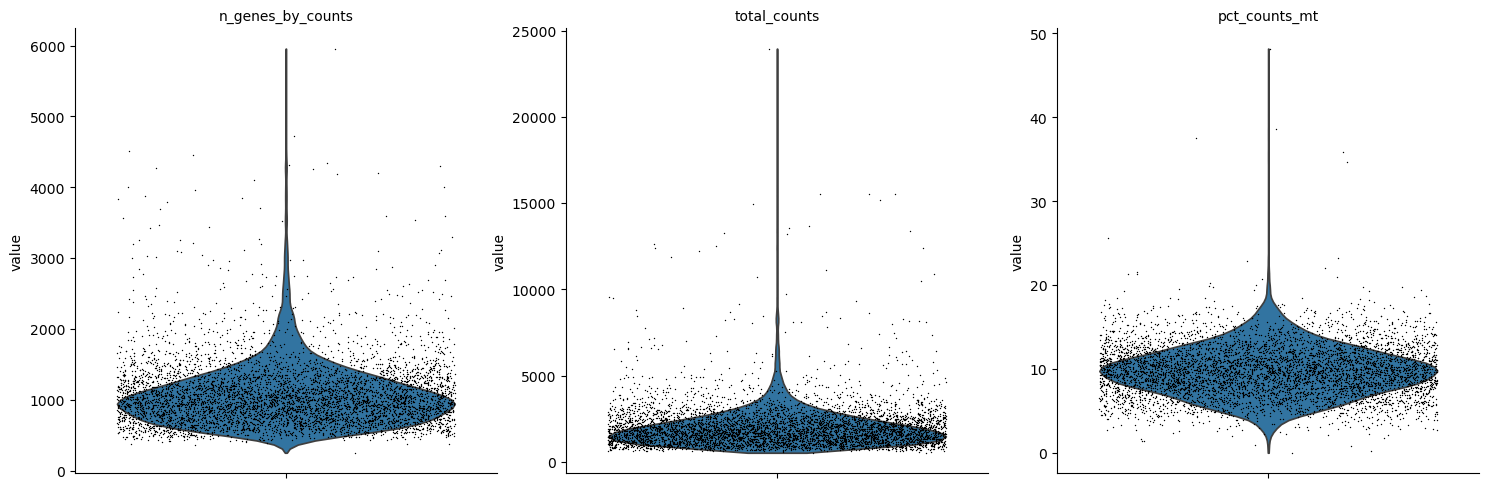

In [39]:
sc.pl.violin(
    rna,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

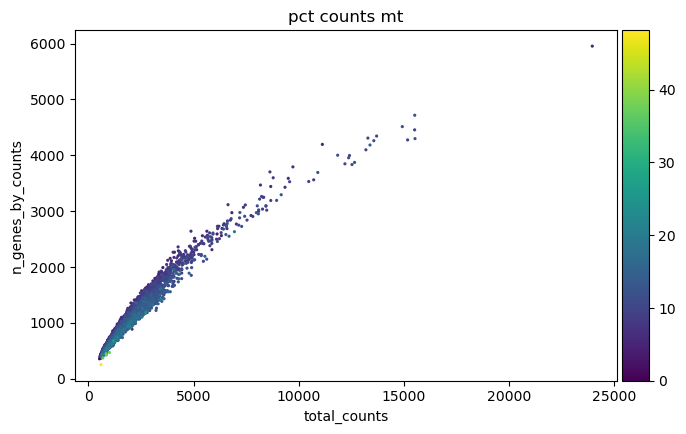

In [40]:
sc.pl.scatter(rna, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [41]:
#filter cells with less than 100 genes expressed and genes that are detected in less than 3 cells.
sc.pp.filter_cells(rna, min_genes=100)
sc.pp.filter_genes(rna, min_cells=3)

In [42]:
rna.obs.columns

Index(['Cell_Type_Experimental', 'Total_VDJ_Read_Count',
       'Total_VDJ_Molecule_Count', 'TCR_Alpha_Gamma_V_gene_Dominant',
       'TCR_Alpha_Gamma_J_gene_Dominant', 'TCR_Alpha_Gamma_C_gene_Dominant',
       'TCR_Alpha_Gamma_CDR3_Nucleotide_Dominant',
       'TCR_Alpha_Gamma_CDR3_Translation_Dominant',
       'TCR_Alpha_Gamma_Read_Count', 'TCR_Alpha_Gamma_Molecule_Count',
       'TCR_Beta_Delta_V_gene_Dominant', 'TCR_Beta_Delta_D_gene_Dominant',
       'TCR_Beta_Delta_J_gene_Dominant', 'TCR_Beta_Delta_C_gene_Dominant',
       'TCR_Beta_Delta_CDR3_Nucleotide_Dominant',
       'TCR_Beta_Delta_CDR3_Translation_Dominant', 'TCR_Beta_Delta_Read_Count',
       'TCR_Beta_Delta_Molecule_Count', 'TCR_Paired_Chains',
       'High_Quality_Cell', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
    

In [43]:
!pip install scikit-image

In [44]:
#scikit-image is needed here
# adds doublet score to .obs
#sc.pp.scrublet(rna, batch_key="sample")
sc.pp.scrublet(rna)
# Doublets can mimic hybrid cell types and confound interpretation. Removing them improves clustering and marker discovery

In [45]:
# Saving count data
rna.layers["counts"] = rna.X.copy()

In [46]:
# Normalizing to median total counts ## other options are- ten thousand (CP10k) or one million (CPM, counts per million)
sc.pp.normalize_total(rna)
# Logarithmize the data
sc.pp.log1p(rna)
## Puts all cells on the same scale

In [47]:
# feature selection
sc.pp.highly_variable_genes(rna, n_top_genes=2000)
## capture most of the meaningful heterogeneity
### used in PCA

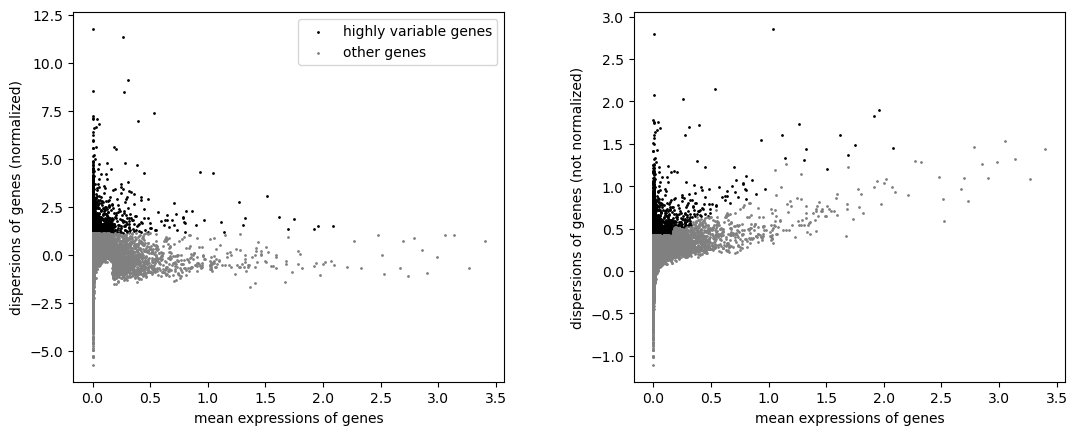

In [48]:
sc.pl.highly_variable_genes(rna)

In [49]:
#pca is not in the mu obj
sc.tl.pca(rna)

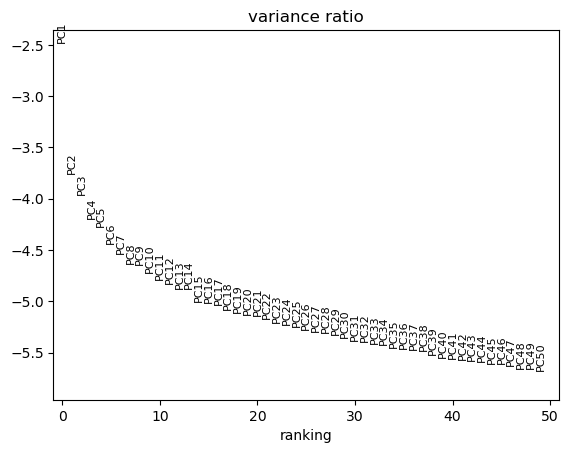

In [50]:
#var. ratio - pca ## elbow plot
sc.pl.pca_variance_ratio(rna, n_pcs=50, log=True)

In [51]:
# pc = 15 decided for now

In [52]:
sc.pp.neighbors(rna, n_neighbors=15, n_pcs=20)

In [53]:
rna

AnnData object with n_obs × n_vars = 5755 × 23691
    obs: 'Cell_Type_Experimental', 'Total_VDJ_Read_Count', 'Total_VDJ_Molecule_Count', 'TCR_Alpha_Gamma_V_gene_Dominant', 'TCR_Alpha_Gamma_J_gene_Dominant', 'TCR_Alpha_Gamma_C_gene_Dominant', 'TCR_Alpha_Gamma_CDR3_Nucleotide_Dominant', 'TCR_Alpha_Gamma_CDR3_Translation_Dominant', 'TCR_Alpha_Gamma_Read_Count', 'TCR_Alpha_Gamma_Molecule_Count', 'TCR_Beta_Delta_V_gene_Dominant', 'TCR_Beta_Delta_D_gene_Dominant', 'TCR_Beta_Delta_J_gene_Dominant', 'TCR_Beta_Delta_C_gene_Dominant', 'TCR_Beta_Delta_CDR3_Nucleotide_Dominant', 'TCR_Beta_Delta_CDR3_Translation_Dominant', 'TCR_Beta_Delta_Read_Count', 'TCR_Beta_Delta_Molecule_Count', 'TCR_Paired_Chains', 'High_Quality_Cell', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_c

In [54]:
# stored here - obsp: 'distances', 'connectivities', uns='neighbors'

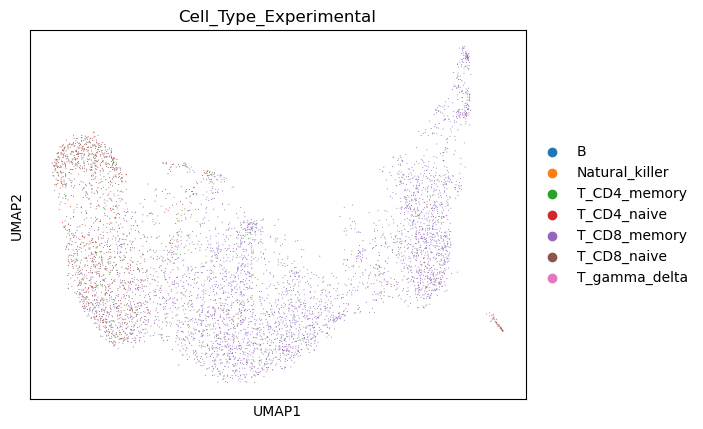

In [55]:
sc.pl.umap(
    rna,
    color="Cell_Type_Experimental",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

In [56]:
# leiden - clust.
## Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
### Clusters correspond to cell types or states
sc.tl.leiden(rna, flavor="igraph", n_iterations=2)

In [57]:
#rna
## leiden= uns

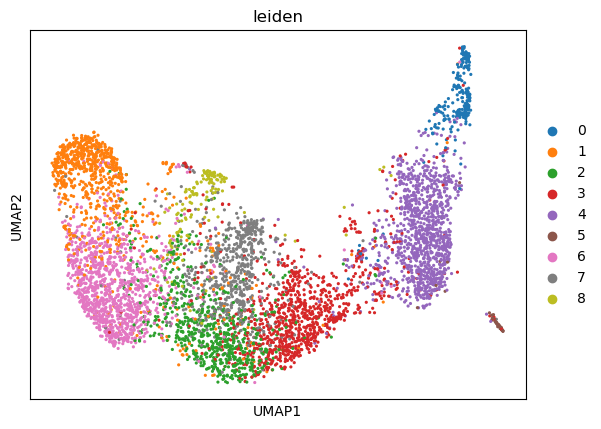

In [58]:
sc.pl.umap(rna, color=["leiden"])

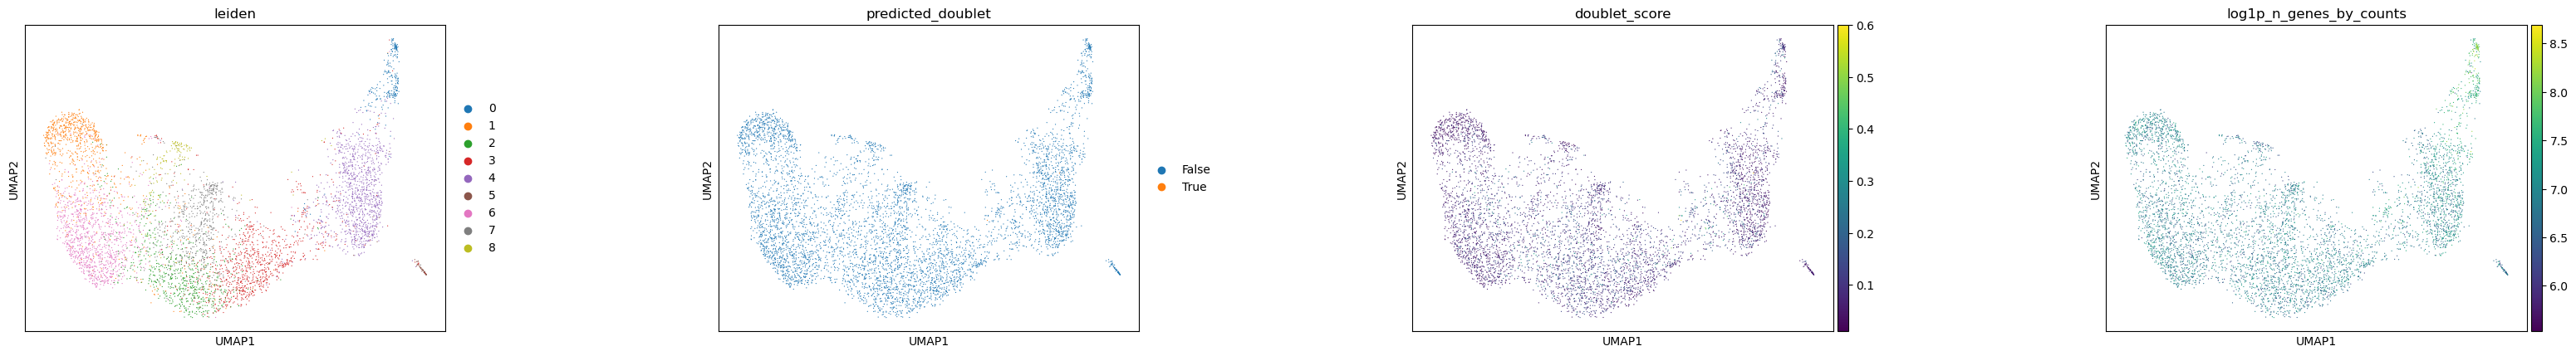

In [59]:
sc.pl.umap(
    rna,
    color=["leiden", "predicted_doublet", "doublet_score", "log1p_n_genes_by_counts"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
)

# Checking whether doublets cluster separately or if high gene counts correspond to outliers # seems fine

In [60]:
# further clustering for cell annotation
for res in [0.02, 0.5, 2.0]:
    sc.tl.leiden(
        rna, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph"
    )

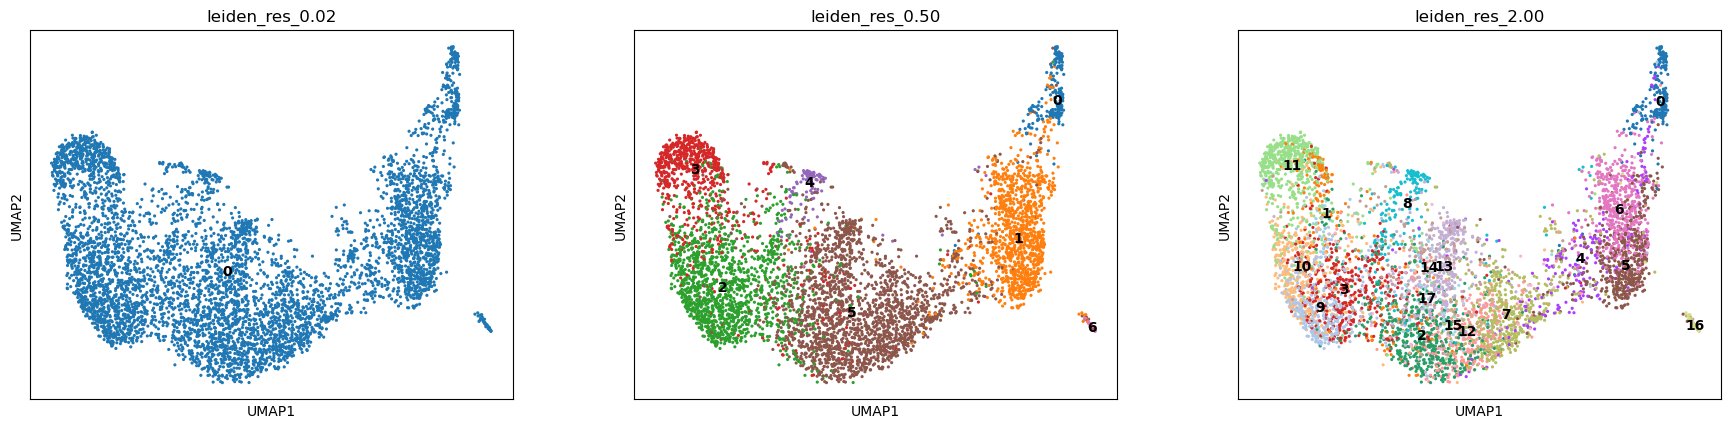

In [61]:
sc.pl.umap(
    rna,
    color=["leiden_res_0.02", "leiden_res_0.50", "leiden_res_2.00"],
    legend_loc="on data",
)

In [62]:
# This could be majorily updated to assign cluster identities for meaningful interpret..
marker_genes = {
    "B cells": ["Ms4a1", "Cd19"],
    "Monocytes/Macrophages": ["Cd14", "Lyz2", "Fcgr3", "Ms4a7", "Fcer1g", "Cst3", "H2-Aa", "Ly6d"],
    "rRNA": ["AY036118", "Gm42418"],  
    "M phase": ["Cenpa", "Ccnb2", "Birc5", "Mki67"],
    "S phase": ["Pcna", "Mcm3", "Ccne2"],
    "T cells": ["Cd8b", "Cd8a", "Cd4", "Cd3g", "Cd3e", "Cd3d"]
}

In [63]:
#sc.pl.dotplot(rna, marker_genes, groupby="leiden_res_2.00", standard_scale="var")
#sc.pl.dotplot(rna, marker_genes, groupby="leiden_res_0.50", standard_scale="var")

In [64]:
# supervised method

In [65]:
marker_genes_upper = {
    k: [g.upper() for g in v] for k, v in marker_genes.items()
}

#sc.pl.dotplot(rna, marker_genes_upper, groupby="leiden_res_2.00", standard_scale="var")
#sc.pl.dotplot(rna, marker_genes_upper, groupby="leiden_res_0.50", standard_scale="var")

In [66]:
all_markers = [g for genes in marker_genes_upper.values() for g in genes] # return g for genese in .values() and append to all markers
missing = [g for g in all_markers if g not in rna.var_names]
print("Missing marker genes:", missing)

Missing marker genes: ['CD19', 'LYZ2', 'FCGR3', 'MS4A7', 'H2-AA', 'LY6D', 'AY036118', 'GM42418']


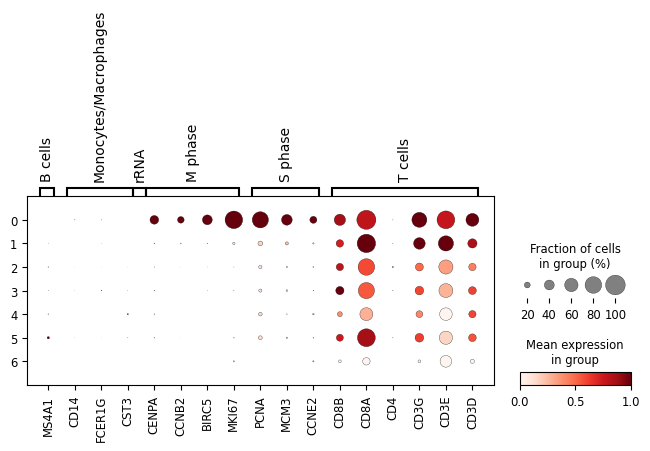

In [67]:
marker_genes_filtered = {
    k: [g for g in v if g not in missing]
    for k, v in marker_genes_upper.items()
}

sc.pl.dotplot(rna, marker_genes_filtered, groupby="leiden_res_0.50", standard_scale="var")

Cluster 0 - High expression of cytotoxic T cells (CD8A, CD8B, CD3D, CD3E) - proliferating (S & M phase markers - cycling T cells/progenitor cells)
Cluster 1 - Mod. exp of T cells, less cell cycle markers - Resting T (Naive/Memory)
Cluster 2 - low active
Cluster 5 - B cells small & CD8A

In [68]:
# unsupervised method

In [69]:
# wilcoxon - comp. cluster vs rest
## Obtain cluster-specific differentially expressed genes
### Identify marker genes for each cluster
sc.tl.rank_genes_groups(rna, groupby="leiden_res_0.50", method="wilcoxon")

In [70]:
rna # `"rank_genes_groups"`

AnnData object with n_obs × n_vars = 5755 × 23691
    obs: 'Cell_Type_Experimental', 'Total_VDJ_Read_Count', 'Total_VDJ_Molecule_Count', 'TCR_Alpha_Gamma_V_gene_Dominant', 'TCR_Alpha_Gamma_J_gene_Dominant', 'TCR_Alpha_Gamma_C_gene_Dominant', 'TCR_Alpha_Gamma_CDR3_Nucleotide_Dominant', 'TCR_Alpha_Gamma_CDR3_Translation_Dominant', 'TCR_Alpha_Gamma_Read_Count', 'TCR_Alpha_Gamma_Molecule_Count', 'TCR_Beta_Delta_V_gene_Dominant', 'TCR_Beta_Delta_D_gene_Dominant', 'TCR_Beta_Delta_J_gene_Dominant', 'TCR_Beta_Delta_C_gene_Dominant', 'TCR_Beta_Delta_CDR3_Nucleotide_Dominant', 'TCR_Beta_Delta_CDR3_Translation_Dominant', 'TCR_Beta_Delta_Read_Count', 'TCR_Beta_Delta_Molecule_Count', 'TCR_Paired_Chains', 'High_Quality_Cell', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_c

In [71]:
rna.uns["rank_genes_groups"]["names"].dtype.names # 6 clusters as per umap plot

('0', '1', '2', '3', '4', '5', '6')

In [72]:
sc.get.rank_genes_groups_df(rna, group="3").head(5)

,names,scores,logfoldchanges,pvals,pvals_adj
0,PABPC1,24.361254,1.070465,4.405373e-131,3.478923e-127
1,RPS6,23.512861,1.019915,3.012895e-122,1.427570e-118
2,EEF1A1,22.770111,0.758693,9.071524e-115,3.581891e-111
3,RPS13,22.763035,1.023195,1.066076e-114,3.608059e-111
4,RPL34,22.679779,0.925342,7.094319e-114,2.100894e-110


In [73]:
sc.get.rank_genes_groups_df(rna, group="3").tail(5)

,names,scores,logfoldchanges,pvals,pvals_adj
23686,HLA-B,-20.925678,-0.419617,3.125881e-97,6.171270e-94
23687,CD74,-22.316282,-2.009389,2.567787e-110,6.759270e-107
23688,DUSP4,-23.596548,-4.500629,4.181765e-123,2.476755e-119
23689,ZFP36,-24.424515,-1.642110,9.390516e-132,1.112354e-127
23690,CCL5,-24.545362,-3.164994,4.847374e-133,1.148391e-128


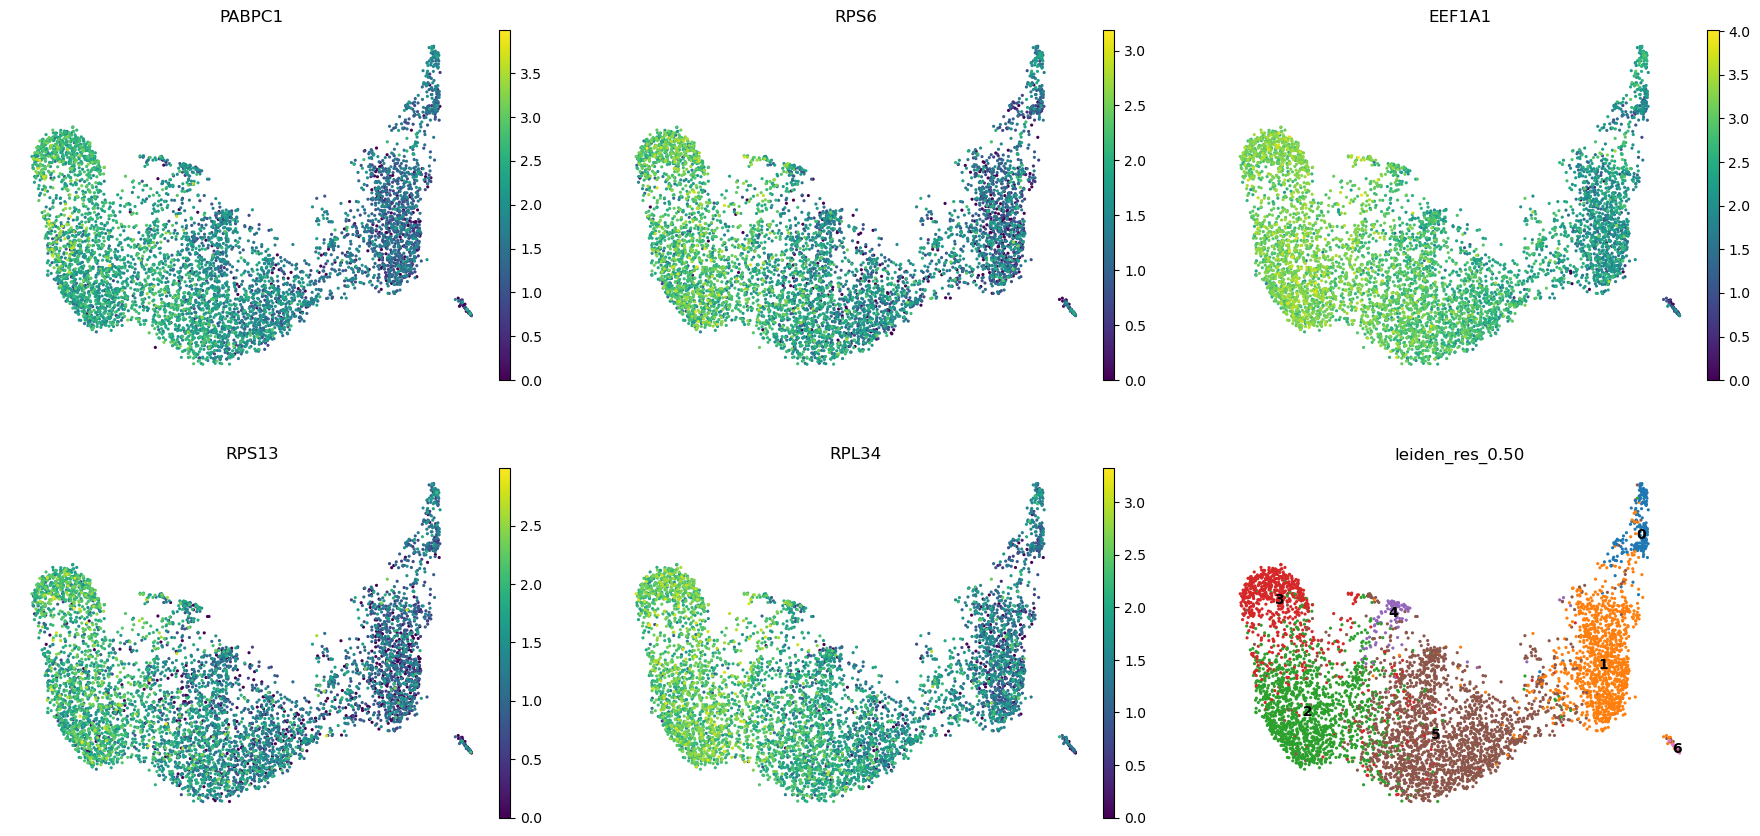

In [74]:
dc_cluster_genes = sc.get.rank_genes_groups_df(rna, group="3").head(5)["names"]
sc.pl.umap(
    rna,
    color=[*dc_cluster_genes, "leiden_res_0.50"],
    legend_loc="on data",
    frameon=False,
    ncols=3,
)
# cluster 3 chosen. Functional relevance to be looked up. 
## seems representative enuf

In [75]:
# use .var_names_make_unique() if multi modalities with same var name present

### Preprocessing and clustering 3k PBMCs (legacy workflow)

In [76]:
result = rna.uns["rank_genes_groups"]
groups = result["names"].dtype.names
pd.DataFrame(
    {
        f"{group}_{key[:1]}": result[key][group]
        for group in groups
        for key in ["names", "pvals"]
    }
).head(5)

,0_n,0_p,1_n,1_p,2_n,2_p,3_n,3_p,4_n,4_p,5_n,5_p,6_n,6_p
0,HMGN2,3.506304e-122,DUSP4,0.000000e+00,EEF1A1,8.427772e-239,PABPC1,4.405373e-131,HSPA1A,3.240652e-47,DUSP2,1.134831e-169,PDE3B,1.129865e-24
1,TUBB,1.410766e-121,CCL5,1.650678e-225,FTH1,7.135565e-237,RPS6,3.012895e-122,FOSB,8.371682e-36,GZMK,3.732681e-118,LINC-PINT,3.969993e-20
2,STMN1,9.115166e-117,RBPJ,5.543782e-222,RPL34,1.655502e-226,EEF1A1,9.071524e-115,HSP90AA1,8.394767e-36,CCL5,1.042662e-77,MALAT1,1.206463e-15
3,TUBA1B,2.189369e-112,HLA-DRB1,6.375882e-201,ANXA1,7.953903e-221,RPS13,1.066076e-114,HSPA1B,2.184209e-30,BTG1,1.051078e-77,SYTL3,2.592683e-12
4,HMGB2,2.143046e-105,RGS1,2.406876e-186,TPT1,6.818152e-219,RPL34,7.094319e-114,DNAJB1,7.322381e-30,RUNX3,3.173097e-77,SIK3,7.571691e-11


In [77]:
# can I use premade database to group these into bio. groups?
## Scanpy's sc.tl.ingest() #tried later, CellTypist or SingleR (R)

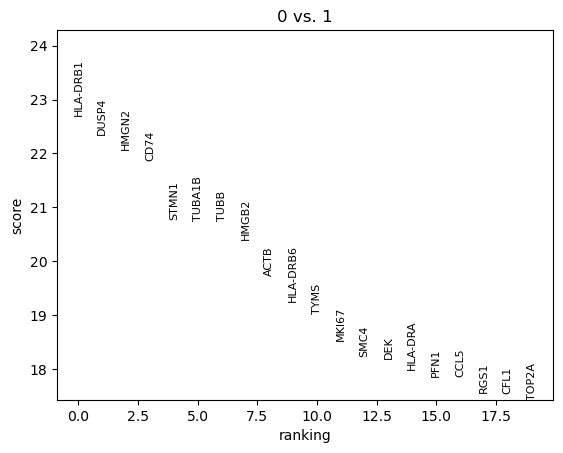

In [78]:
# comparing single clusters ## here cluster 0 vs cluster 1
sc.tl.rank_genes_groups(rna, "leiden", groups=["0"], reference="1", method="wilcoxon")
sc.pl.rank_genes_groups(rna, groups=["0"], n_genes=20)
## Use cases - distinguish between similar T cell subtypes, tumor vs immune cells

In [79]:
rna.obs["leiden_res_0.50"].unique()
cluster_ids = rna.obs["leiden_res_0.50"].unique().tolist()

Comparing cluster 0 vs cluster 2


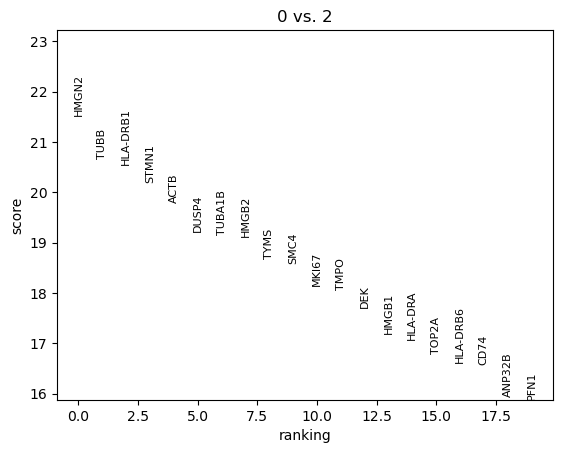

Comparing cluster 0 vs cluster 5


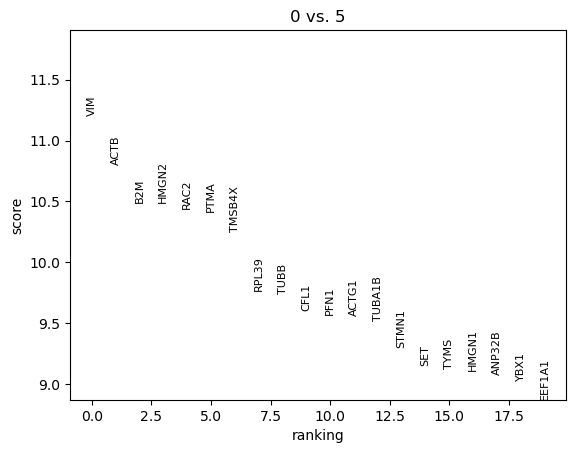

Comparing cluster 0 vs cluster 1


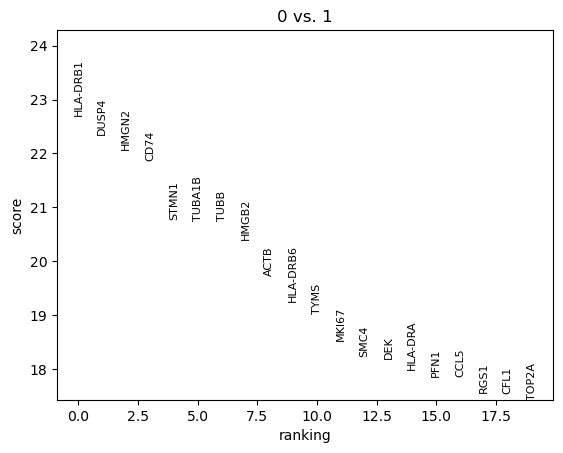

Comparing cluster 0 vs cluster 3


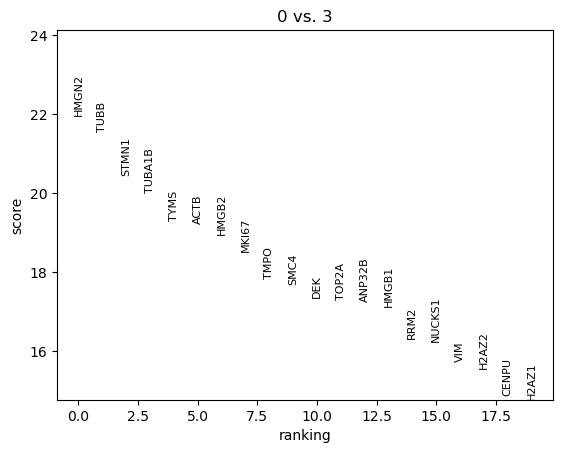

Comparing cluster 0 vs cluster 6


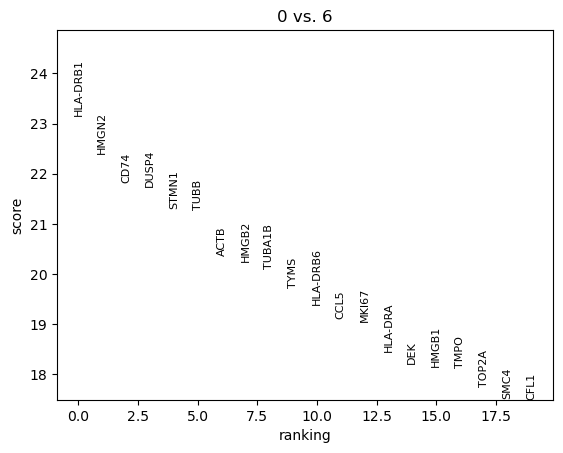

Comparing cluster 0 vs cluster 4


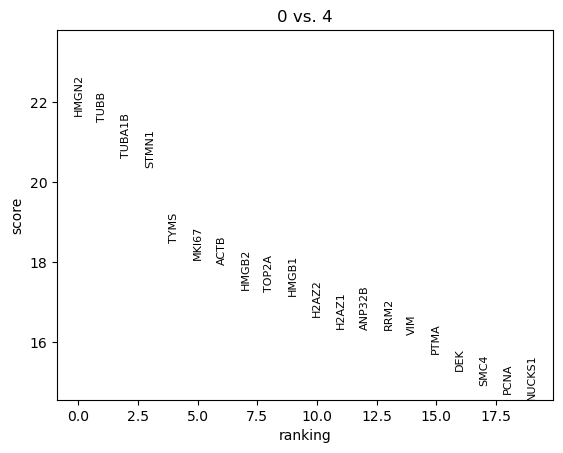

Comparing cluster 2 vs cluster 5


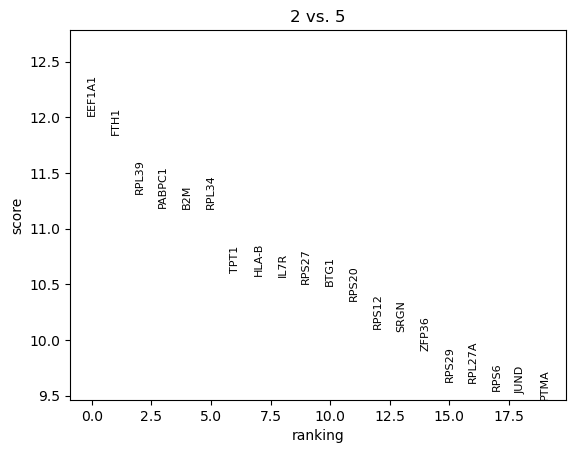

Comparing cluster 2 vs cluster 1


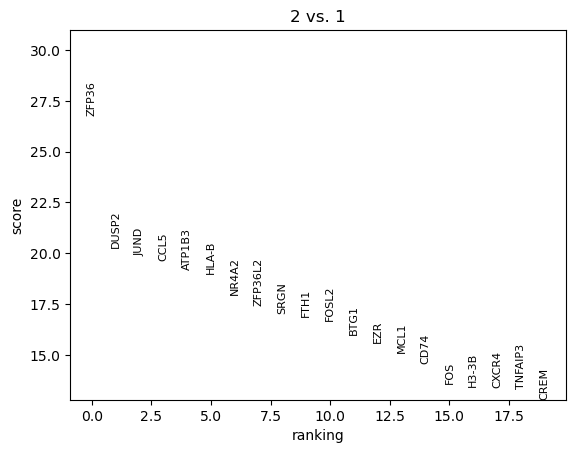

Comparing cluster 2 vs cluster 3


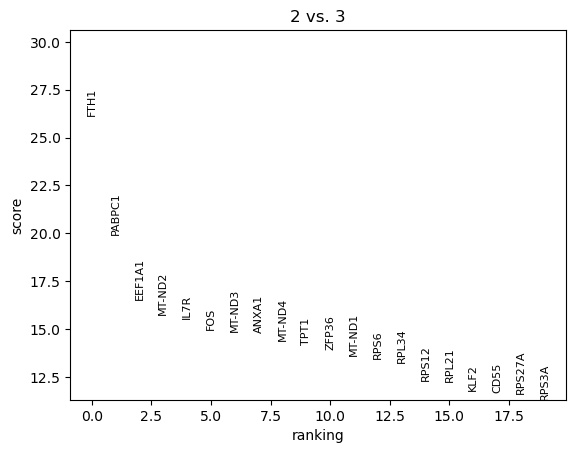

Comparing cluster 2 vs cluster 6


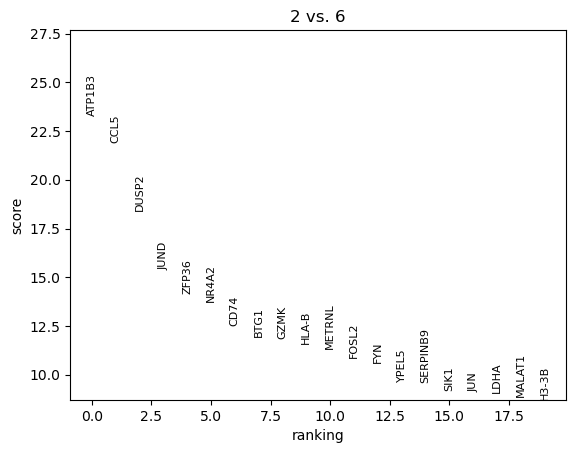

Comparing cluster 2 vs cluster 4


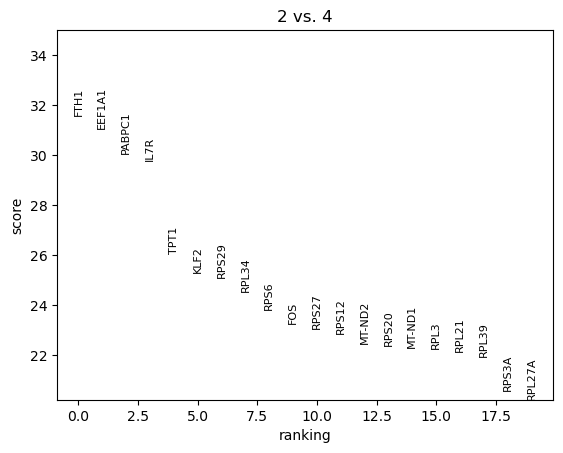

Comparing cluster 5 vs cluster 1


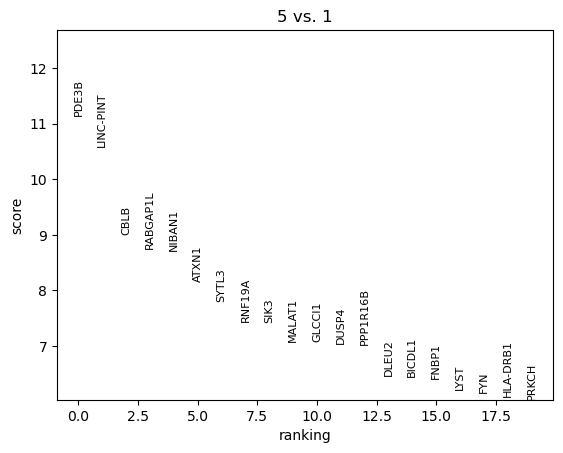

Comparing cluster 5 vs cluster 3


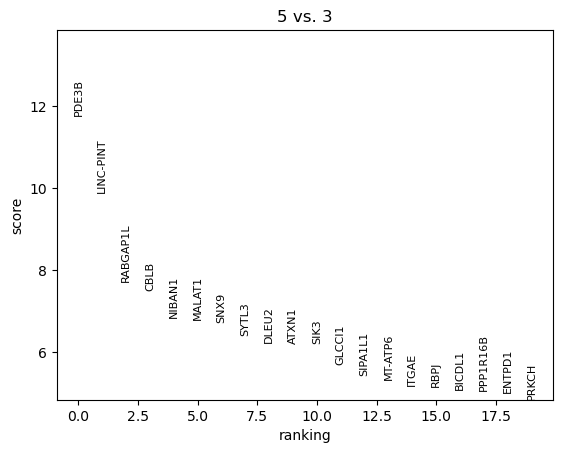

Comparing cluster 5 vs cluster 6


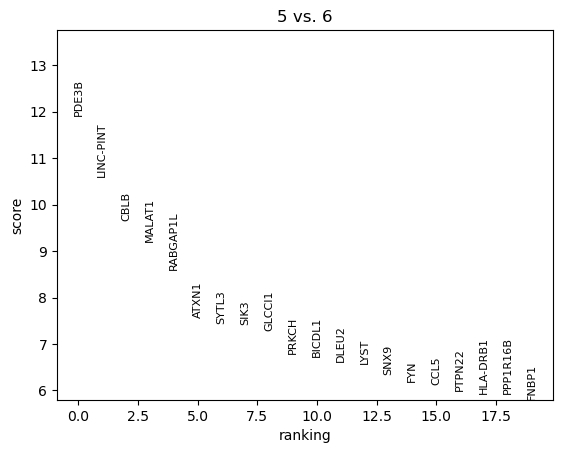

Comparing cluster 5 vs cluster 4


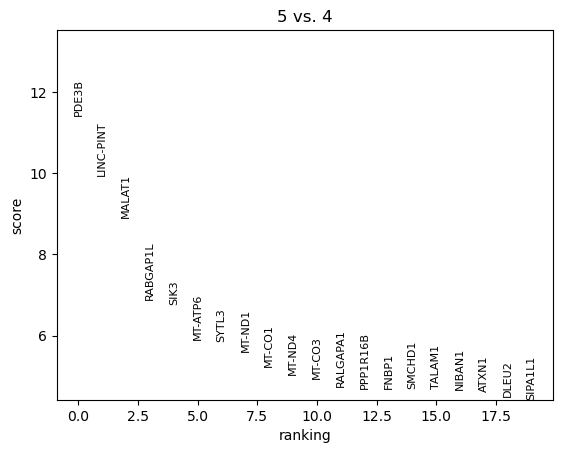

Comparing cluster 1 vs cluster 3


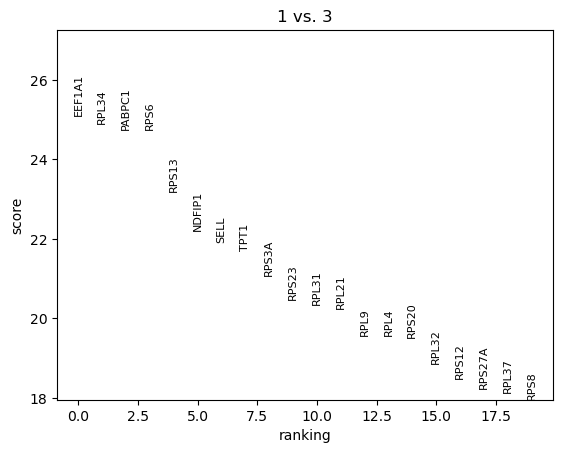

Comparing cluster 1 vs cluster 6


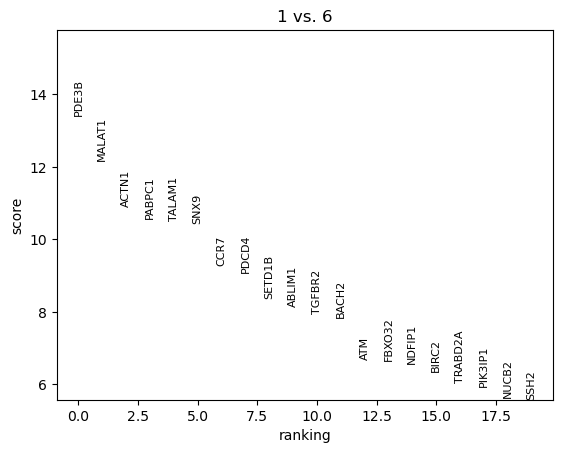

Comparing cluster 1 vs cluster 4


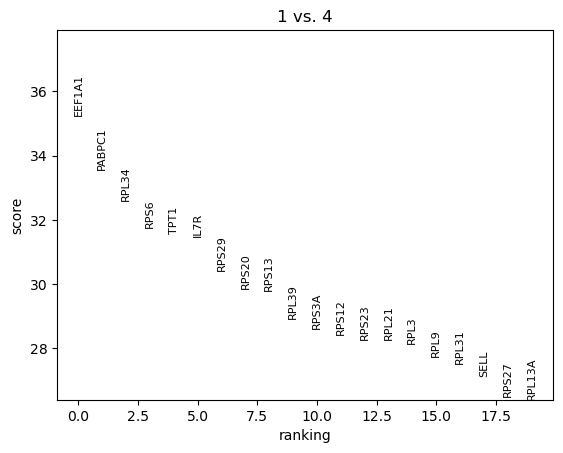

Comparing cluster 3 vs cluster 6


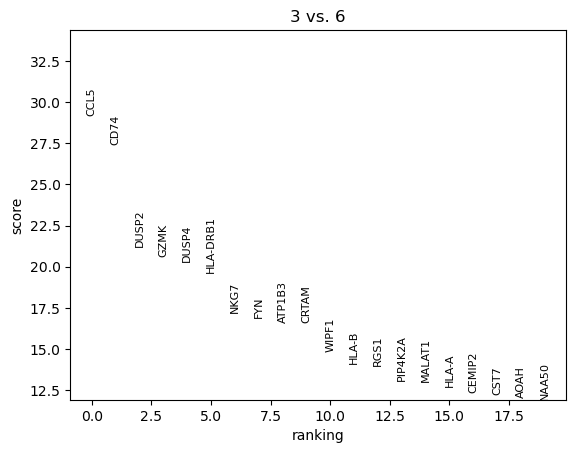

Comparing cluster 3 vs cluster 4


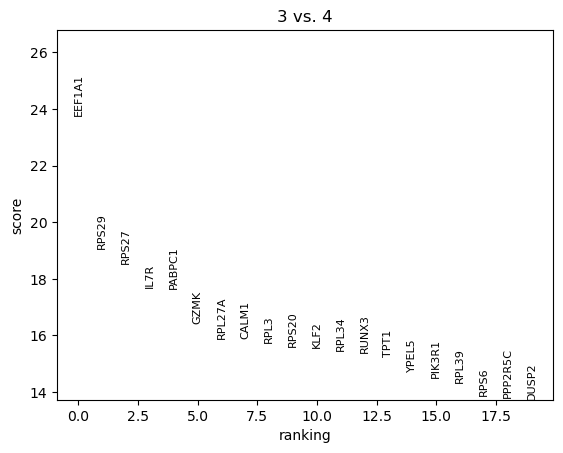

Comparing cluster 6 vs cluster 4


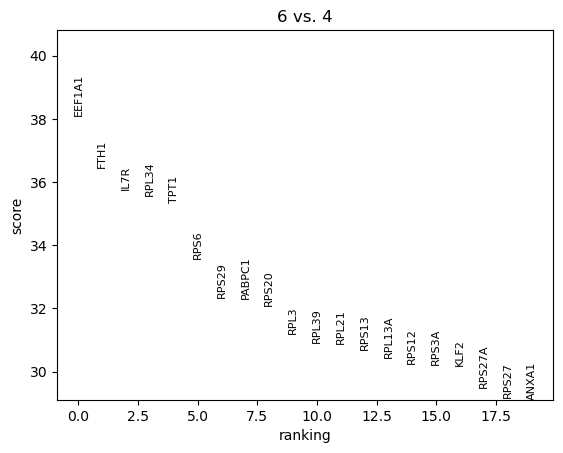

In [80]:
from itertools import combinations

for i, j in combinations(cluster_ids, 2):
    print(f"Comparing cluster {i} vs cluster {j}")
    sc.tl.rank_genes_groups(rna, "leiden", groups=[i], reference=j, method="wilcoxon")
    sc.pl.rank_genes_groups(rna, groups=[i], n_genes=20, show=True)


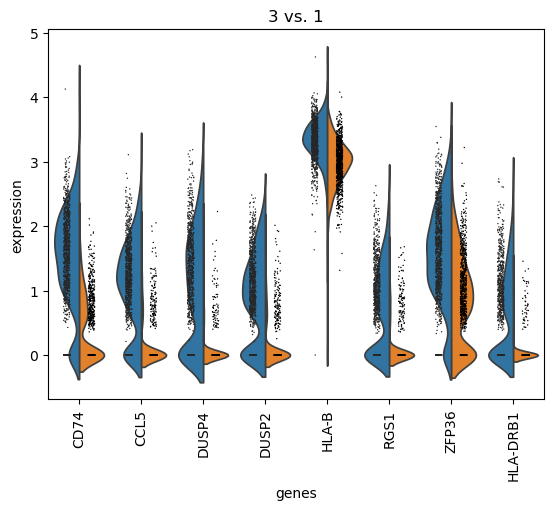

In [81]:
# violin plots ## clus - 3 against cluster 1
sc.tl.rank_genes_groups(rna, groupby="leiden", groups=["3"], reference="1", method="wilcoxon")
sc.pl.rank_genes_groups_violin(rna, groups="3", n_genes=8)
# to identify heterogeneity
## cluster 3 upregulates the all genes under cons. as compared to clus. 1. Func. relevance of each gene to be looked up

In [82]:
rna

AnnData object with n_obs × n_vars = 5755 × 23691
    obs: 'Cell_Type_Experimental', 'Total_VDJ_Read_Count', 'Total_VDJ_Molecule_Count', 'TCR_Alpha_Gamma_V_gene_Dominant', 'TCR_Alpha_Gamma_J_gene_Dominant', 'TCR_Alpha_Gamma_C_gene_Dominant', 'TCR_Alpha_Gamma_CDR3_Nucleotide_Dominant', 'TCR_Alpha_Gamma_CDR3_Translation_Dominant', 'TCR_Alpha_Gamma_Read_Count', 'TCR_Alpha_Gamma_Molecule_Count', 'TCR_Beta_Delta_V_gene_Dominant', 'TCR_Beta_Delta_D_gene_Dominant', 'TCR_Beta_Delta_J_gene_Dominant', 'TCR_Beta_Delta_C_gene_Dominant', 'TCR_Beta_Delta_CDR3_Nucleotide_Dominant', 'TCR_Beta_Delta_CDR3_Translation_Dominant', 'TCR_Beta_Delta_Read_Count', 'TCR_Beta_Delta_Molecule_Count', 'TCR_Paired_Chains', 'High_Quality_Cell', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_c

In [83]:
# save step # .raw attribute
rna.raw = rna
rna.raw.to_adata().write("./patient070_withoutX.h5ad")

In [84]:
# BBKNN is a fast and intuitive batch effect removal tool that can be directly used in the scanpy workflow. 
##It serves as an alternative to scanpy.pp.neighbors()
### Equivalent to rpca integration
#### Also harmony, mnn, scVI (DL) - external mods #### scVI seems interesting - https://docs.scvi-tools.org/en/1.0.0/tutorials/notebooks/harmonization.html
#####cca is more correction, rpca assumes pca and then corrects lightly?
######bbknn also assumes pca & quick neighbourhood graph correction
#######Integration - shared cell types, trajectories

### Steps

1. Processing

2. Normalize --equivalent to SCTransform for both patient data

3. TCR data using scirpy

4. Normalize

4. Integrate both objects

# Ingest integ.

### Adding a new patient to an existing annotated atlas

In [85]:
import anndata
import scanpy as sc
import pandas as pd

In [86]:
sc.settings.verbosity = 1  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_versions()
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor="white")

-----
anndata     0.11.3
scanpy      1.10.4
-----
Cython                      3.0.12
PIL                         11.1.0
anyio                       NA
arrow                       1.3.0
asciitree                   NA
asttokens                   NA
attr                        25.3.0
attrs                       25.3.0
awkward                     2.8.1
awkward_cpp                 NA
babel                       2.17.0
backports                   NA
brotli                      1.1.0
celltypist                  1.6.3
certifi                     2025.01.31
cffi                        1.17.1
charset_normalizer          3.4.1
cloudpickle                 3.1.1
colorama                    0.4.6
comm                        0.2.2
cycler                      0.12.1
cython                      3.0.12
cython_runtime              NA
cytoolz                     1.0.1
dask                        2024.11.2
dateutil                    2.9.0.post0
debugpy                     1.8.13
decorator                 

In [87]:
sc.pp.filter_cells(rna, min_genes=200)
sc.pp.filter_genes(rna, min_cells=3)
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=2000, subset=True)
sc.pp.scale(rna, max_value=10)
sc.tl.pca(rna, svd_solver='arpack')
sc.pp.neighbors(rna)
sc.tl.umap(rna)
sc.tl.leiden(rna)

In [88]:
# patient 2
patient_data071 = mu.read_h5mu("/home/rstudio/run071/run071-nsclc-4.h5mu")
rna_2 = patient_data071.mod['rna']

In [89]:
rna_2

AnnData object with n_obs × n_vars = 804 × 22940
    obs: 'Cell_Type_Experimental', 'Total_VDJ_Read_Count', 'Total_VDJ_Molecule_Count', 'TCR_Alpha_Gamma_V_gene_Dominant', 'TCR_Alpha_Gamma_J_gene_Dominant', 'TCR_Alpha_Gamma_C_gene_Dominant', 'TCR_Alpha_Gamma_CDR3_Nucleotide_Dominant', 'TCR_Alpha_Gamma_CDR3_Translation_Dominant', 'TCR_Alpha_Gamma_Read_Count', 'TCR_Alpha_Gamma_Molecule_Count', 'TCR_Beta_Delta_V_gene_Dominant', 'TCR_Beta_Delta_D_gene_Dominant', 'TCR_Beta_Delta_J_gene_Dominant', 'TCR_Beta_Delta_C_gene_Dominant', 'TCR_Beta_Delta_CDR3_Nucleotide_Dominant', 'TCR_Beta_Delta_CDR3_Translation_Dominant', 'TCR_Beta_Delta_Read_Count', 'TCR_Beta_Delta_Molecule_Count', 'TCR_Paired_Chains', 'High_Quality_Cell'
    var: 'Raw_Reads', 'Raw_Molecules', 'Raw_Seq_Depth', 'RSEC_Adjusted_Molecules', 'RSEC_Adjusted_Reads_non-singleton', 'RSEC_Adjusted_Molecules_non-singleton'
    uns: 'Pipeline_Inputs', 'Pipeline_Metrics'
    obsm: 'X_tsne', 'X_umap'

In [90]:
sc.pp.filter_cells(rna_2, min_genes=200)
sc.pp.filter_genes(rna_2, min_cells=3)
sc.pp.normalize_total(rna_2, target_sum=1e4)
sc.pp.log1p(rna_2)

In [91]:
# retain only common genes
common_genes = rna.var_names.intersection(rna_2.var_names)
rna = rna[:, common_genes].copy()
rna_2 = rna_2[:, common_genes].copy()

In [92]:
# ingesting based on leiden clust. alg.
sc.tl.ingest(rna_2, rna, obs='leiden')

Cluster annotations from patient 070 are projected onto 071 via nearest neighbor transfer
Great if one (ref) is well annotated

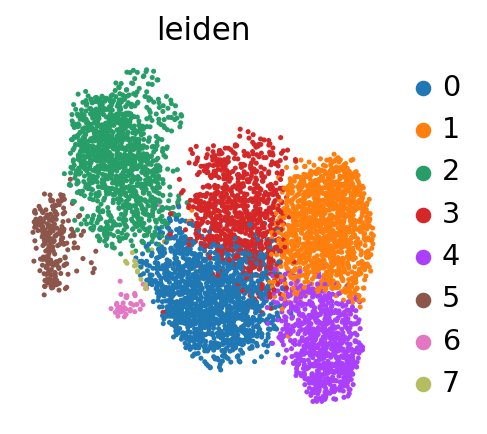

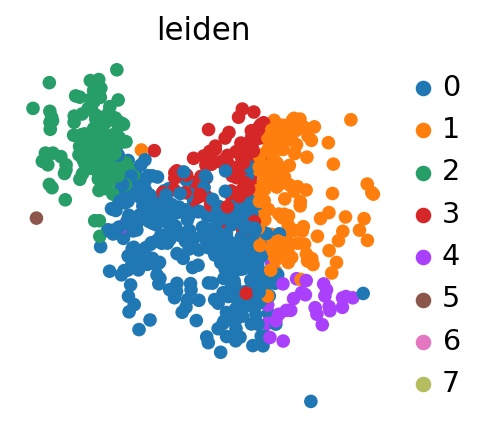

In [93]:
# now using leiden, plot
## patient 2 object now uses patient 1 as reference
### here for leiden - umap
sc.pl.umap(rna, color='leiden')
sc.pl.umap(rna_2, color='leiden')

In [94]:
rna.obs['leiden'].value_counts()

leiden
0    1412
1    1272
2    1179
3     844
4     765
5     230
6      39
7      14
Name: count, dtype: int64

In [95]:
rna_2.obs['leiden'].value_counts()

leiden
0    362
2    156
1    149
3    104
4     30
5      1
6      0
7      0
Name: count, dtype: int64

In [96]:
# maybe the diff. would be more evident with a well annotated set

## BBKNN integ.

In [97]:
rna

AnnData object with n_obs × n_vars = 5755 × 1167
    obs: 'Cell_Type_Experimental', 'Total_VDJ_Read_Count', 'Total_VDJ_Molecule_Count', 'TCR_Alpha_Gamma_V_gene_Dominant', 'TCR_Alpha_Gamma_J_gene_Dominant', 'TCR_Alpha_Gamma_C_gene_Dominant', 'TCR_Alpha_Gamma_CDR3_Nucleotide_Dominant', 'TCR_Alpha_Gamma_CDR3_Translation_Dominant', 'TCR_Alpha_Gamma_Read_Count', 'TCR_Alpha_Gamma_Molecule_Count', 'TCR_Beta_Delta_V_gene_Dominant', 'TCR_Beta_Delta_D_gene_Dominant', 'TCR_Beta_Delta_J_gene_Dominant', 'TCR_Beta_Delta_C_gene_Dominant', 'TCR_Beta_Delta_CDR3_Nucleotide_Dominant', 'TCR_Beta_Delta_CDR3_Translation_Dominant', 'TCR_Beta_Delta_Read_Count', 'TCR_Beta_Delta_Molecule_Count', 'TCR_Paired_Chains', 'High_Quality_Cell', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_co

In [98]:
rna_2

AnnData object with n_obs × n_vars = 802 × 1167
    obs: 'Cell_Type_Experimental', 'Total_VDJ_Read_Count', 'Total_VDJ_Molecule_Count', 'TCR_Alpha_Gamma_V_gene_Dominant', 'TCR_Alpha_Gamma_J_gene_Dominant', 'TCR_Alpha_Gamma_C_gene_Dominant', 'TCR_Alpha_Gamma_CDR3_Nucleotide_Dominant', 'TCR_Alpha_Gamma_CDR3_Translation_Dominant', 'TCR_Alpha_Gamma_Read_Count', 'TCR_Alpha_Gamma_Molecule_Count', 'TCR_Beta_Delta_V_gene_Dominant', 'TCR_Beta_Delta_D_gene_Dominant', 'TCR_Beta_Delta_J_gene_Dominant', 'TCR_Beta_Delta_C_gene_Dominant', 'TCR_Beta_Delta_CDR3_Nucleotide_Dominant', 'TCR_Beta_Delta_CDR3_Translation_Dominant', 'TCR_Beta_Delta_Read_Count', 'TCR_Beta_Delta_Molecule_Count', 'TCR_Paired_Chains', 'High_Quality_Cell', 'n_genes', 'leiden'
    var: 'Raw_Reads', 'Raw_Molecules', 'Raw_Seq_Depth', 'RSEC_Adjusted_Molecules', 'RSEC_Adjusted_Reads_non-singleton', 'RSEC_Adjusted_Molecules_non-singleton', 'n_cells'
    uns: 'Pipeline_Inputs', 'Pipeline_Metrics', 'log1p', 'leiden_colors'
    obsm: 'X_tsn

In [99]:
# adding a batch tag
rna.obs['batch'] = 'patient1'
rna_2.obs['batch'] = 'patient2'

In [100]:
merged_object = rna.concatenate(rna_2, batch_key='batch')

In [101]:
#import numpy as np

# Ensure X is dense
#X_dense = merged_object.X.toarray() if hasattr(merged_object.X, "toarray") else merged_object.X

# Now check for NaNs
#nan_cells = np.any(np.isnan(X_dense), axis=1)

# Filter out those cells
#merged_object = merged_object[~nan_cells].copy()

In [102]:
# preprocessing as before
#sc.pp.filter_cells(merged_object, min_genes=200)
#sc.pp.filter_genes(merged_object, min_cells=3)
#sc.pp.normalize_total(merged_object, target_sum=1e4)
#sc.pp.log1p(merged_object)
sc.pp.highly_variable_genes(merged_object, n_top_genes=2000, subset=True)
sc.pp.scale(merged_object, max_value=10)
sc.tl.pca(merged_object, n_comps=20, svd_solver='arpack')
sc.pp.neighbors(merged_object)
sc.tl.umap(merged_object)
sc.tl.leiden(merged_object)

In [103]:
sc.pp.highly_variable_genes(merged_object, n_top_genes=2000, subset=True)
sc.pp.scale(merged_object, max_value=10)
sc.tl.pca(merged_object, n_comps=20, svd_solver='arpack')
sc.pp.neighbors(merged_object)
sc.tl.umap(merged_object)
sc.tl.leiden(merged_object)

In [104]:
!pip install bbknn

In [105]:
sc.external.pp.bbknn(merged_object, batch_key="batch")
# aligns batches while preserving biological variability

In [106]:
sc.tl.umap(merged_object)

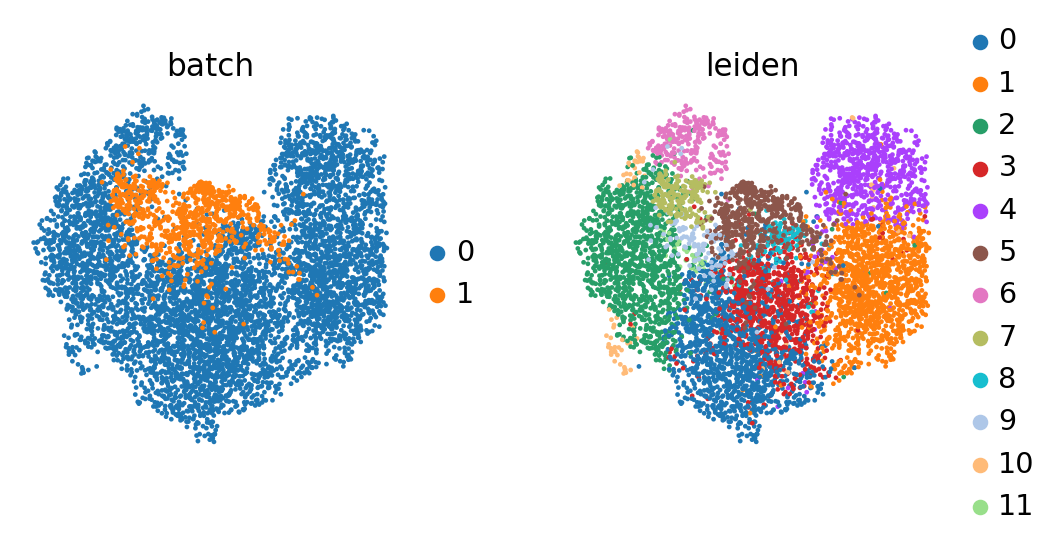

In [107]:
sc.pl.umap(merged_object, color=["batch", "leiden"])

In [108]:
# 0 is reference and 1 is the new dataset
## Need better labelling
### good batch correction here, in ingest-based plot the boundaries were shifted slightly, maybe not true integration like here
#### ingest maybe good for classification acc. to a refrence

In [109]:
from scipy import sparse
sparse.issparse(merged_object.X)

False

## Cell types conserved across batches

In [110]:
print(rna_2.obs.columns)

Index(['Cell_Type_Experimental', 'Total_VDJ_Read_Count',
       'Total_VDJ_Molecule_Count', 'TCR_Alpha_Gamma_V_gene_Dominant',
       'TCR_Alpha_Gamma_J_gene_Dominant', 'TCR_Alpha_Gamma_C_gene_Dominant',
       'TCR_Alpha_Gamma_CDR3_Nucleotide_Dominant',
       'TCR_Alpha_Gamma_CDR3_Translation_Dominant',
       'TCR_Alpha_Gamma_Read_Count', 'TCR_Alpha_Gamma_Molecule_Count',
       'TCR_Beta_Delta_V_gene_Dominant', 'TCR_Beta_Delta_D_gene_Dominant',
       'TCR_Beta_Delta_J_gene_Dominant', 'TCR_Beta_Delta_C_gene_Dominant',
       'TCR_Beta_Delta_CDR3_Nucleotide_Dominant',
       'TCR_Beta_Delta_CDR3_Translation_Dominant', 'TCR_Beta_Delta_Read_Count',
       'TCR_Beta_Delta_Molecule_Count', 'TCR_Paired_Chains',
       'High_Quality_Cell', 'n_genes', 'leiden', 'batch'],
      dtype='object')


In [111]:
# Assigning cell types to a new column in the reference
rna.obs['celltype'] = rna.obs['Cell_Type_Experimental'].astype('category')

In [112]:
# Ingest cell types
## Earlier only leiden was ingested

sc.tl.ingest(rna_2, rna, obs='celltype')

In [113]:
rna_2.obs['celltype']

111840      T_CD8_memory
146164      T_CD8_memory
166368       T_CD8_naive
205244      T_CD8_memory
289640      T_CD8_memory
                ...     
56227643    T_CD8_memory
56430280    T_CD8_memory
56491109    T_CD8_memory
56566004    T_CD8_memory
56581982    T_CD8_memory
Name: celltype, Length: 802, dtype: category
Categories (7, object): ['B', 'Natural_killer', 'T_CD4_memory', 'T_CD4_naive', 'T_CD8_memory', 'T_CD8_naive', 'T_gamma_delta']

In [114]:
# checking the no. of cell types in patient1 data ~ rna, which was used as a reference here
rna.obs['Cell_Type_Experimental'].value_counts()

Cell_Type_Experimental
T_CD8_memory      3877
T_CD8_naive       1470
T_CD4_naive        208
T_CD4_memory       169
Natural_killer      21
T_gamma_delta        8
B                    2
Name: count, dtype: int64

In [115]:
rna_2.obs['Cell_Type_Experimental'].value_counts()

Cell_Type_Experimental
T_CD8_memory          568
T_CD4_memory           99
T_CD8_naive            76
T_CD4_naive            24
Natural_killer         23
Monocyte_classical      9
Dendritic               2
B                       1
Name: count, dtype: int64

In [116]:
# rna (patient070) is highly T cell dominant
## might not be suitable for annotating rare cell types such as Monocyte_classical, Dendritic etc. in patient071(rna_2)
### good for cd8 vs cd4 classification

In [117]:
rna_2.obs['celltype_orig'] = rna_2.obs['Cell_Type_Experimental']

In [118]:
# intersected categories
conserved_categories = rna_2.obs["celltype"].cat.categories.intersection(
    rna_2.obs["celltype_orig"].cat.categories
)
# intersect categories
obs_query_conserved = rna_2.obs.loc[
    rna_2.obs["celltype"].isin(conserved_categories)
    & rna_2.obs["celltype_orig"].isin(conserved_categories)
].copy()
# remove unused categories
obs_query_conserved["celltype"] = obs_query_conserved[
    "celltype"
].cat.remove_unused_categories()
# remove unused categories and fix category ordering
obs_query_conserved["celltype_orig"] = obs_query_conserved["celltype_orig"].cat.set_categories(
    obs_query_conserved["celltype"].cat.categories
)

In [119]:
pd.crosstab(obs_query_conserved["celltype"], obs_query_conserved["celltype_orig"])

celltype_orig,T_CD8_memory,T_CD8_naive
celltype,,
T_CD8_memory,535,55
T_CD8_naive,33,21


In [122]:
#accuracy estimation step
import numpy as np
cm = pd.crosstab(obs_query_conserved["celltype"], obs_query_conserved["celltype_orig"])
accuracy = np.trace(cm.values) / cm.values.sum()
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 86.34%


The confusion matrix shows that T_CD8_memory cells were mostly correctly predicted (535 out of 590), while T_CD8_naive cells were frequently misclassified — with only 21 correctly labeled and 55 wrongly assigned as memory. This indicates that the ingest-based label transfer is reliable for CD8 memory cells but less accurate for distinguishing naive CD8 cells, possibly due to transcriptional similarity or underrepresentation in the reference.

## Distributions across batch

In [123]:
sc.tl.embedding_density(merged_object, groupby="batch")

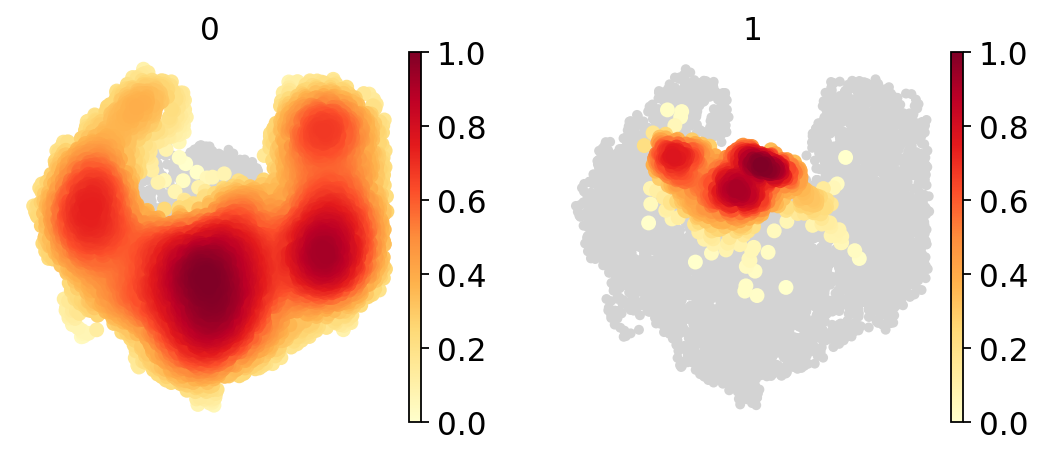

In [124]:
sc.pl.embedding_density(merged_object, groupby="batch")

In [125]:
# Fewer cells and cell type diff. due to that. Not technical batch effect

In [126]:
# scirpy relies on this dependency - pip install python-Levenshtein
## should update scanpy .yml file

In [129]:
#!pip uninstall python-Levenshtein -y
# using conda
#!mamba install -y -n scanpy_v1.10.4_r python-Levenshtein

conda-forge/linux-64                                        Using cache
conda-forge/noarch                                          Using cache

Pinned packages:

  - python=3.10


Transaction

  Prefix: /opt/conda/envs/scanpy_v1.10.4_r

  All requested packages already installed


Transaction starting

Transaction finished



In [133]:
import tarfile
import warnings
from glob import glob

import anndata
import matplotlib.pyplot as plt
import muon as mu
import pandas as pd
import scanpy as sc
import scirpy as ir ## scirpy timee

sc.set_figure_params(figsize=(4, 4))
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

In [134]:
#ir.get.airr(rna, "locus", "VJ_1")
#ir.io.read_airr("/home/rstudio/run070/run070-nsclc-3_VDJ_Dominant_Contigs_AIRR.tsv")
patient070_airr = ir.io.read_airr("/home/rstudio/run070/run070-nsclc-3_VDJ_Dominant_Contigs_AIRR.tsv")

/opt/conda/envs/scanpy_v1.10.4_r/lib/python3.10/site-packages/anndata/utils.py:349: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


In [135]:
patient070_airr

AnnData object with n_obs × n_vars = 5298 × 0
    uns: 'scirpy_version'
    obsm: 'airr'

In [136]:
patient070_airr.obsm["airr"]

<Array [[{c_call: 'TRAC', ...}, ...], ...] type='5298 * var * {c_call: ?str...'>

In [177]:
patient070_airr

AnnData object with n_obs × n_vars = 5298 × 0
    obs: 'receptor_type', 'receptor_subtype', 'chain_pairing'
    uns: 'scirpy_version', 'chain_indices'
    obsm: 'airr', 'chain_indices'

In [178]:
patient070_airr.uns["chain_indices"]

{'model': 'scirpy_dual_ir_v0.13',
 'filter': '[<function index_chains.<locals>.<lambda> at 0x77442f072dd0>, <function index_chains.<locals>.<lambda> at 0x77442f073130>]',
 'airr_key': 'airr',
 'sort_chains_by': "{'umi_count': 0, 'duplicate_count': 0, 'consensus_count': 0, 'junction': '', 'junction_aa': ''}"}

In [138]:
ir.tl.chain_qc(patient070_airr)

Filtering chains...
Indexing VJ chains...
Indexing VDJ chains...
build result array
Stored result in `adata.obs["receptor_type"]`.
Stored result in `adata.obs["receptor_subtype"]`.
Stored result in `adata.obs["chain_pairing"]`.


In [139]:
patient070_airr

AnnData object with n_obs × n_vars = 5298 × 0
    obs: 'receptor_type', 'receptor_subtype', 'chain_pairing'
    uns: 'scirpy_version', 'chain_indices'
    obsm: 'airr', 'chain_indices'

Receptor type (e.g., αβ vs γδ)
Subtype (e.g., naïve vs memory)
Chain pairing type

In [140]:
# Analysis

<Axes: title={'center': 'Number of cells in receptor_type by has_ir'}, xlabel='receptor_type', ylabel='Number of cells'>

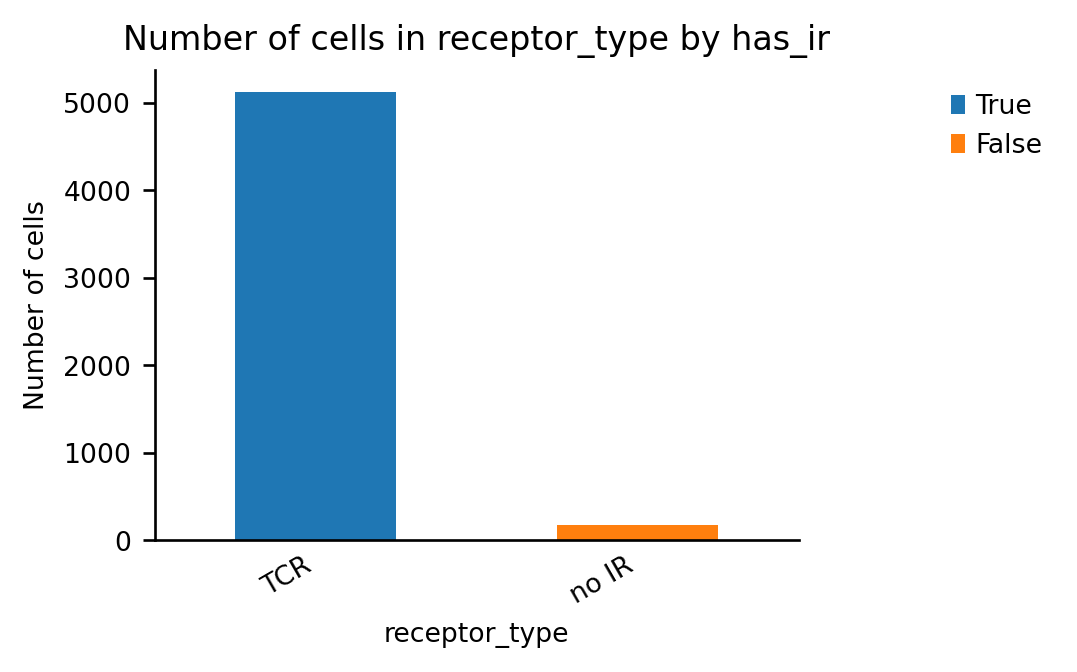

In [141]:
# Receptor type distribution
ir.pl.group_abundance(patient070_airr, groupby="receptor_type")

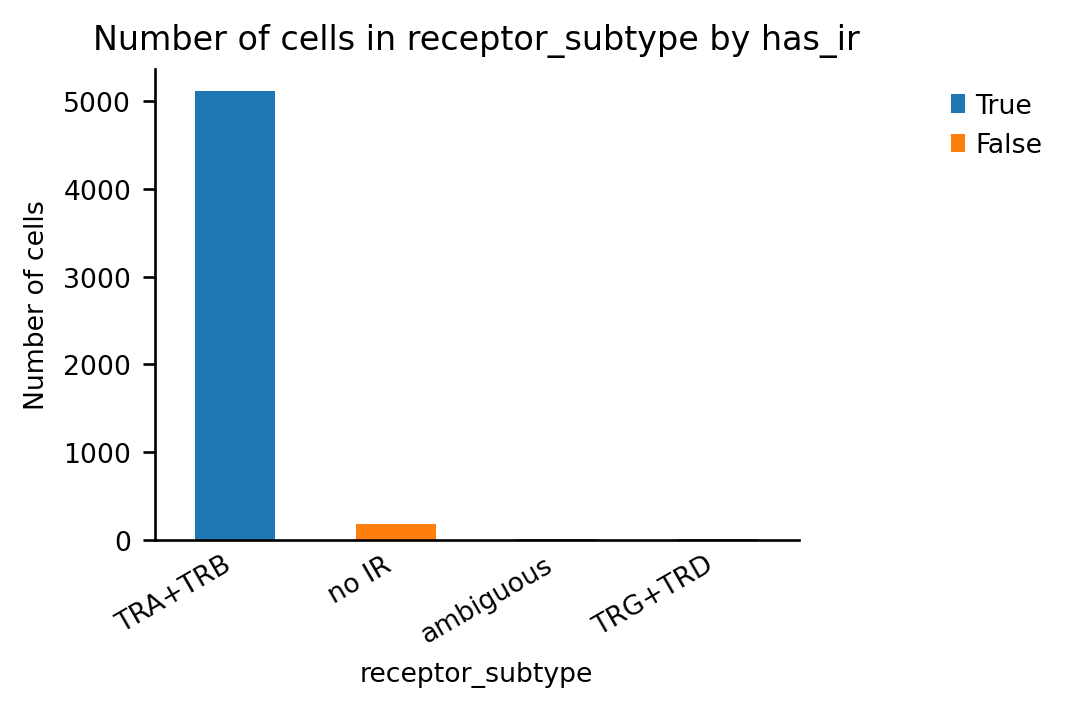

In [142]:
_ = ir.pl.group_abundance(patient070_airr, groupby="receptor_subtype")

<Axes: title={'center': 'Number of cells in chain_pairing by has_ir'}, xlabel='chain_pairing', ylabel='Number of cells'>

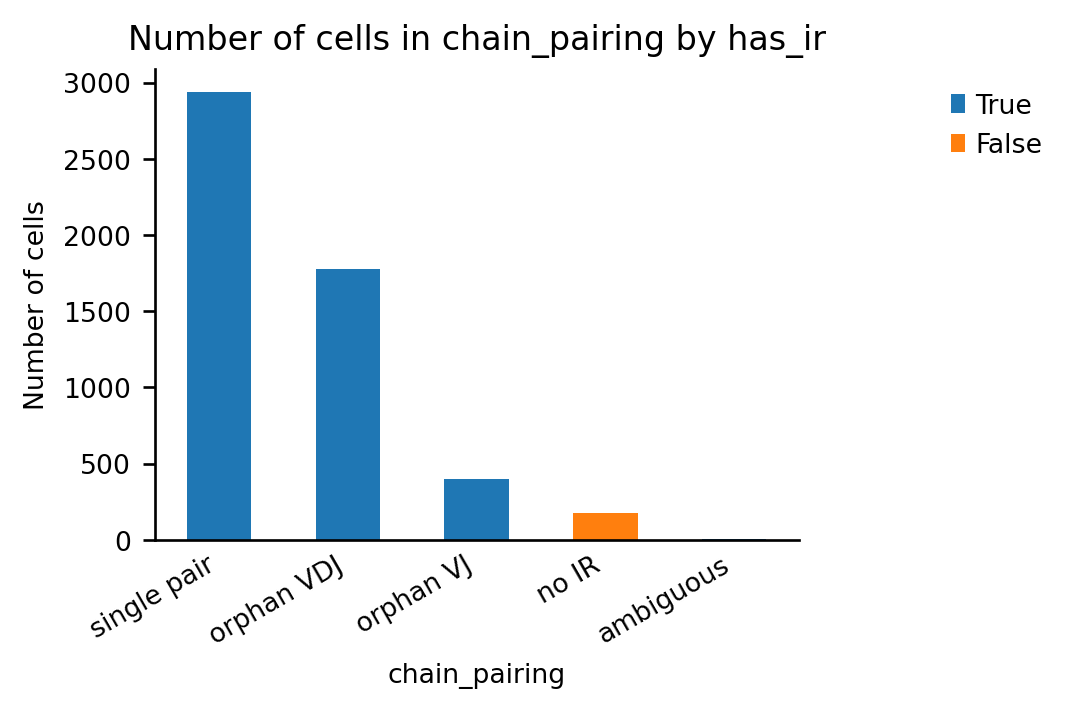

In [143]:
# Chain pairing distribution
ir.pl.group_abundance(patient070_airr, groupby="chain_pairing")

In [144]:
# retrieve the "locus" field of the primary VJ chain for each cell in the patient070 obj.
ir.get.airr(patient070_airr, "locus", "VJ_1")

cell_id
4100         TRA
4977        None
11356        TRA
21277        TRA
30102        TRA
            ... 
56515060     TRA
56516968    None
56533009    None
56555682    None
56588651     TRA
Length: 5298, dtype: object

In [145]:
print(
    "Fraction of cells with more than one pair of TCRs: {:.2f}".format(
        np.sum(patient070_airr.obs["chain_pairing"].isin(["extra VJ", "extra VDJ", "two full chains", "multichain"]))
        / len(patient070_airr)
    )
)

Fraction of cells with more than one pair of TCRs: 0.00


In [146]:
len(patient070_airr.obsm["airr"])

5298

In [147]:
# Cool way of visualizing
with mu.set_options(display_style = "html", display_html_expand = 0b000):
    display(patient_data070)

Using custom muon options in the new context...


rna:Cell_Type_Experimental,category,"T_CD8_memory,T_CD8_naive,T_CD8_memory,T_CD8_memory..."
rna:Total_VDJ_Read_Count,int64,"25473,1846,1170,15606,5071,4516,8921,6125,14902,79..."
rna:Total_VDJ_Molecule_Count,int64,"94,7,4,22,15,10,21,11,28,7,3,12,4,5,1,9,9,6,15,0,1..."
rna:TCR_Alpha_Gamma_V_gene_Dominant,category,"TRAV4*01,,TRAV14/DV4*02,TRAV3*01,TRAV36/DV7*04,,TR..."
rna:TCR_Alpha_Gamma_J_gene_Dominant,category,"TRAJ38*01,,TRAJ17*01,TRAJ50*01,TRAJ57*01,,TRAJ16*0..."
rna:TCR_Alpha_Gamma_C_gene_Dominant,category,"TRAC,,TRAC,TRAC,TRAC,,TRAC,TRAC,TRAC,,TRAC,,,,TRAC..."
rna:TCR_Alpha_Gamma_CDR3_Nucleotide_Dominant,category,"CTCGTGGGTACGGCTGGCAACAACCGTAAGCTGATT,,GCAATGGAAGCT..."
rna:TCR_Alpha_Gamma_CDR3_Translation_Dominant,category,"LVGTAGNNRKLI,,AMEAAGNKLT,AVRAGETSYDKVI,HQGGSEKLV,,..."
rna:TCR_Alpha_Gamma_Read_Count,int64,"13739,0,512,101,2189,0,3659,1034,4088,0,833,0,0,0,..."
rna:TCR_Alpha_Gamma_Molecule_Count,int64,"27,0,2,1,6,0,5,3,10,0,1,0,0,0,1,5,0,0,2,0,0,3,2,3,..."
rna:TCR_Beta_Delta_V_gene_Dominant,category,"TRBV4-1*01,TRBV4-2*01,TRBV19*01,TRBV12-4*01,TRBV4-..."


Returning to the previously defined mudata options: {'display_style': 'text', 'display_html_expand': 2}
Returning to the previously defined muon options: {}


In [148]:
# Only "rna" modality (no "airr" modality present yet)
## combining multiple samples - anndata.concat()

In [149]:
# Seperate modalities like this feels cleaner and more scalable as opposed to combineExpression in Seurat

In [150]:
# annotation
## celltypist installed to conda env

In [151]:
import celltypist
from celltypist import models

In [152]:
# Enabling `force_update = True` will overwrite existing (old) models.
models.download_models(force_update = True)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 54
📂 Storing models in /root/.celltypist/data/models
💾 Downloading model [1/54]: Immune_All_Low.pkl
💾 Downloading model [2/54]: Immune_All_High.pkl
💾 Downloading model [3/54]: Adult_COVID19_PBMC.pkl
💾 Downloading model [4/54]: Adult_CynomolgusMacaque_Hippocampus.pkl
💾 Downloading model [5/54]: Adult_Human_MTG.pkl
💾 Downloading model [6/54]: Adult_Human_PancreaticIslet.pkl
💾 Downloading model [7/54]: Adult_Human_PrefrontalCortex.pkl
💾 Downloading model [8/54]: Adult_Human_Skin.pkl
💾 Downloading model [9/54]: Adult_Human_Vascular.pkl
💾 Downloading model [10/54]: Adult_Mouse_Gut.pkl
💾 Downloading model [11/54]: Adult_Mouse_OlfactoryBulb.pkl
💾 Downloading model [12/54]: Adult_Pig_Hippocampus.pkl
💾 Downloading model [13/54]: Adult_RhesusMacaque_Hippocampus.pkl
💾 Downloading model [14/54]: Autopsy_COVID19_Lung.pkl
💾 Downloading model [15/54]: COVID19_HumanChallenge_Blood.pkl
💾 D

In [153]:
models.models_path

'/root/.celltypist/data/models'

In [154]:
models.models_description()

👉 Detailed model information can be found at `https://www.celltypist.org/models`


,model,description
0,Immune_All_Low.pkl,immune sub-populations combined from 20 tissue...
1,Immune_All_High.pkl,immune populations combined from 20 tissues of...
2,Adult_COVID19_PBMC.pkl,peripheral blood mononuclear cell types from C...
3,Adult_CynomolgusMacaque_Hippocampus.pkl,cell types from the hippocampus of adult cynom...
4,Adult_Human_MTG.pkl,cell types and subtypes (10x-based) from the a...
5,Adult_Human_PancreaticIslet.pkl,cell types from pancreatic islets of healthy a...
6,Adult_Human_PrefrontalCortex.pkl,cell types and subtypes from the adult human d...
7,Adult_Human_Skin.pkl,cell types from human healthy adult skin
8,Adult_Human_Vascular.pkl,vascular populations combined from multiple ad...
9,Adult_Mouse_Gut.pkl,cell types in the adult mouse gut combined fro...


In [155]:
model = models.Model.load(model = 'Immune_All_Low.pkl')

In [156]:
# check 
model.cell_types

array(['Age-associated B cells', 'Alveolar macrophages', 'B cells',
       'CD16+ NK cells', 'CD16- NK cells', 'CD8a/a', 'CD8a/b(entry)',
       'CMP', 'CRTAM+ gamma-delta T cells', 'Classical monocytes',
       'Cycling B cells', 'Cycling DCs', 'Cycling NK cells',
       'Cycling T cells', 'Cycling gamma-delta T cells',
       'Cycling monocytes', 'DC', 'DC precursor', 'DC1', 'DC2', 'DC3',
       'Double-negative thymocytes', 'Double-positive thymocytes', 'ELP',
       'ETP', 'Early MK', 'Early erythroid', 'Early lymphoid/T lymphoid',
       'Endothelial cells', 'Epithelial cells', 'Erythrocytes',
       'Erythrophagocytic macrophages', 'Fibroblasts',
       'Follicular B cells', 'Follicular helper T cells', 'GMP',
       'Germinal center B cells', 'Granulocytes', 'HSC/MPP',
       'Hofbauer cells', 'ILC', 'ILC precursor', 'ILC1', 'ILC2', 'ILC3',
       'Intermediate macrophages', 'Intestinal macrophages',
       'Kidney-resident macrophages', 'Kupffer cells',
       'Large pre-B cell

In [189]:
# lop1p & normalize before doing prediction with celltypist
#sc.pp.normalize_total(rna_2)
# Logarithmize the data
#sc.pp.log1p(rna_2)

normalizing counts per cell
    finished (0:00:00)


In [235]:
sc.tl.leiden(rna_2, resolution=0.8)

running Leiden clustering
    finished: found 7 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


In [236]:
# Not run; predict cell identities using this loaded model.
#predictions = celltypist.annotate(adata_2000, model = model, majority_voting = True)
# Alternatively, just specify the model name (recommended as this ensures the model is intact every time it is loaded).
#choosing rna here
predictions = celltypist.annotate(rna_2, model = 'Immune_All_Low.pkl', majority_voting = True)

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 802 cells and 1167 genes
🔗 Matching reference genes in the model
🧬 494 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5


running Leiden clustering
    finished: found 41 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:00)


🗳️ Majority voting the predictions
✅ Majority voting done!


In [237]:
predictions.predicted_labels

,predicted_labels,over_clustering,majority_voting
111840,Type 1 helper T cells,4,Tem/Temra cytotoxic T cells
146164,Tem/Trm cytotoxic T cells,27,Tem/Trm cytotoxic T cells
166368,Tcm/Naive helper T cells,9,Tem/Effector helper T cells
205244,DC,0,Tem/Trm cytotoxic T cells
289640,Tem/Trm cytotoxic T cells,24,Tem/Trm cytotoxic T cells
...,...,...,...
56227643,Type 1 helper T cells,16,Double-positive thymocytes
56430280,NK cells,31,Tem/Trm cytotoxic T cells
56491109,Tem/Trm cytotoxic T cells,17,Tem/Trm cytotoxic T cells
56566004,Tcm/Naive cytotoxic T cells,9,Tem/Effector helper T cells


In [238]:
rna_2.uns['over_clustering']

{'params': {'resolution': 5, 'random_state': 0, 'n_iterations': -1}}

In [239]:
# Get an `AnnData` with predicted labels embedded into the cell metadata columns.
adata = predictions.to_adata()

In [240]:
adata

AnnData object with n_obs × n_vars = 802 × 1167
    obs: 'Cell_Type_Experimental', 'Total_VDJ_Read_Count', 'Total_VDJ_Molecule_Count', 'TCR_Alpha_Gamma_V_gene_Dominant', 'TCR_Alpha_Gamma_J_gene_Dominant', 'TCR_Alpha_Gamma_C_gene_Dominant', 'TCR_Alpha_Gamma_CDR3_Nucleotide_Dominant', 'TCR_Alpha_Gamma_CDR3_Translation_Dominant', 'TCR_Alpha_Gamma_Read_Count', 'TCR_Alpha_Gamma_Molecule_Count', 'TCR_Beta_Delta_V_gene_Dominant', 'TCR_Beta_Delta_D_gene_Dominant', 'TCR_Beta_Delta_J_gene_Dominant', 'TCR_Beta_Delta_C_gene_Dominant', 'TCR_Beta_Delta_CDR3_Nucleotide_Dominant', 'TCR_Beta_Delta_CDR3_Translation_Dominant', 'TCR_Beta_Delta_Read_Count', 'TCR_Beta_Delta_Molecule_Count', 'TCR_Paired_Chains', 'High_Quality_Cell', 'n_genes', 'leiden', 'batch', 'celltype', 'celltype_orig', 'predicted_labels', 'majority_voting', 'conf_score', 'over_clustering'
    var: 'Raw_Reads', 'Raw_Molecules', 'Raw_Seq_Depth', 'RSEC_Adjusted_Molecules', 'RSEC_Adjusted_Reads_non-singleton', 'RSEC_Adjusted_Molecules_non-s

In [241]:
sc.set_figure_params(figsize=(10, 8))

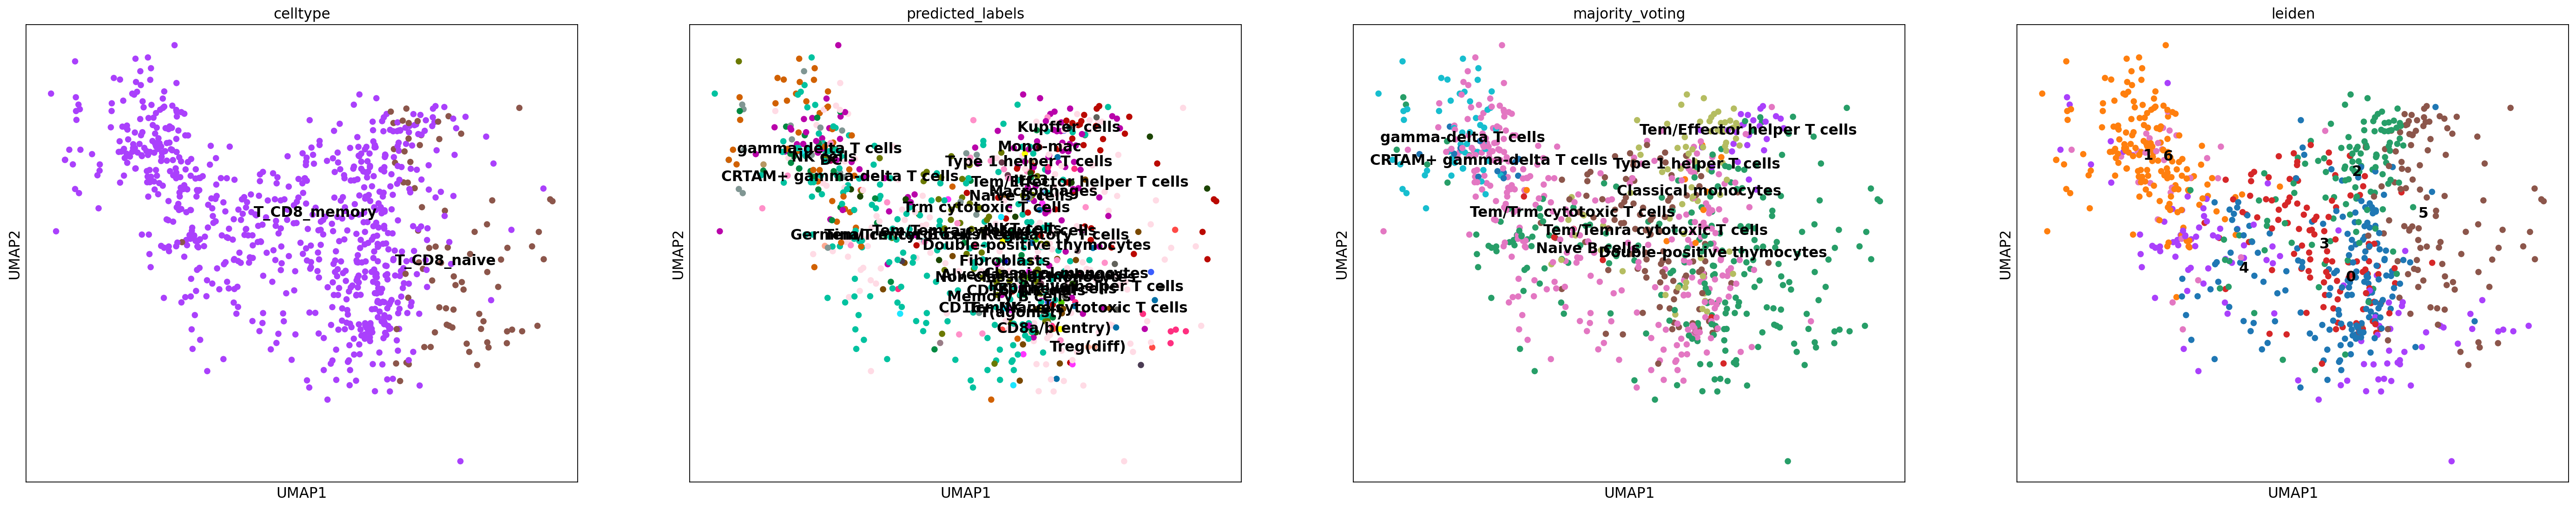

In [242]:
sc.pl.umap(
    adata,
    color=['celltype', 'predicted_labels', 'majority_voting', 'leiden'],
    legend_loc='on data'
)

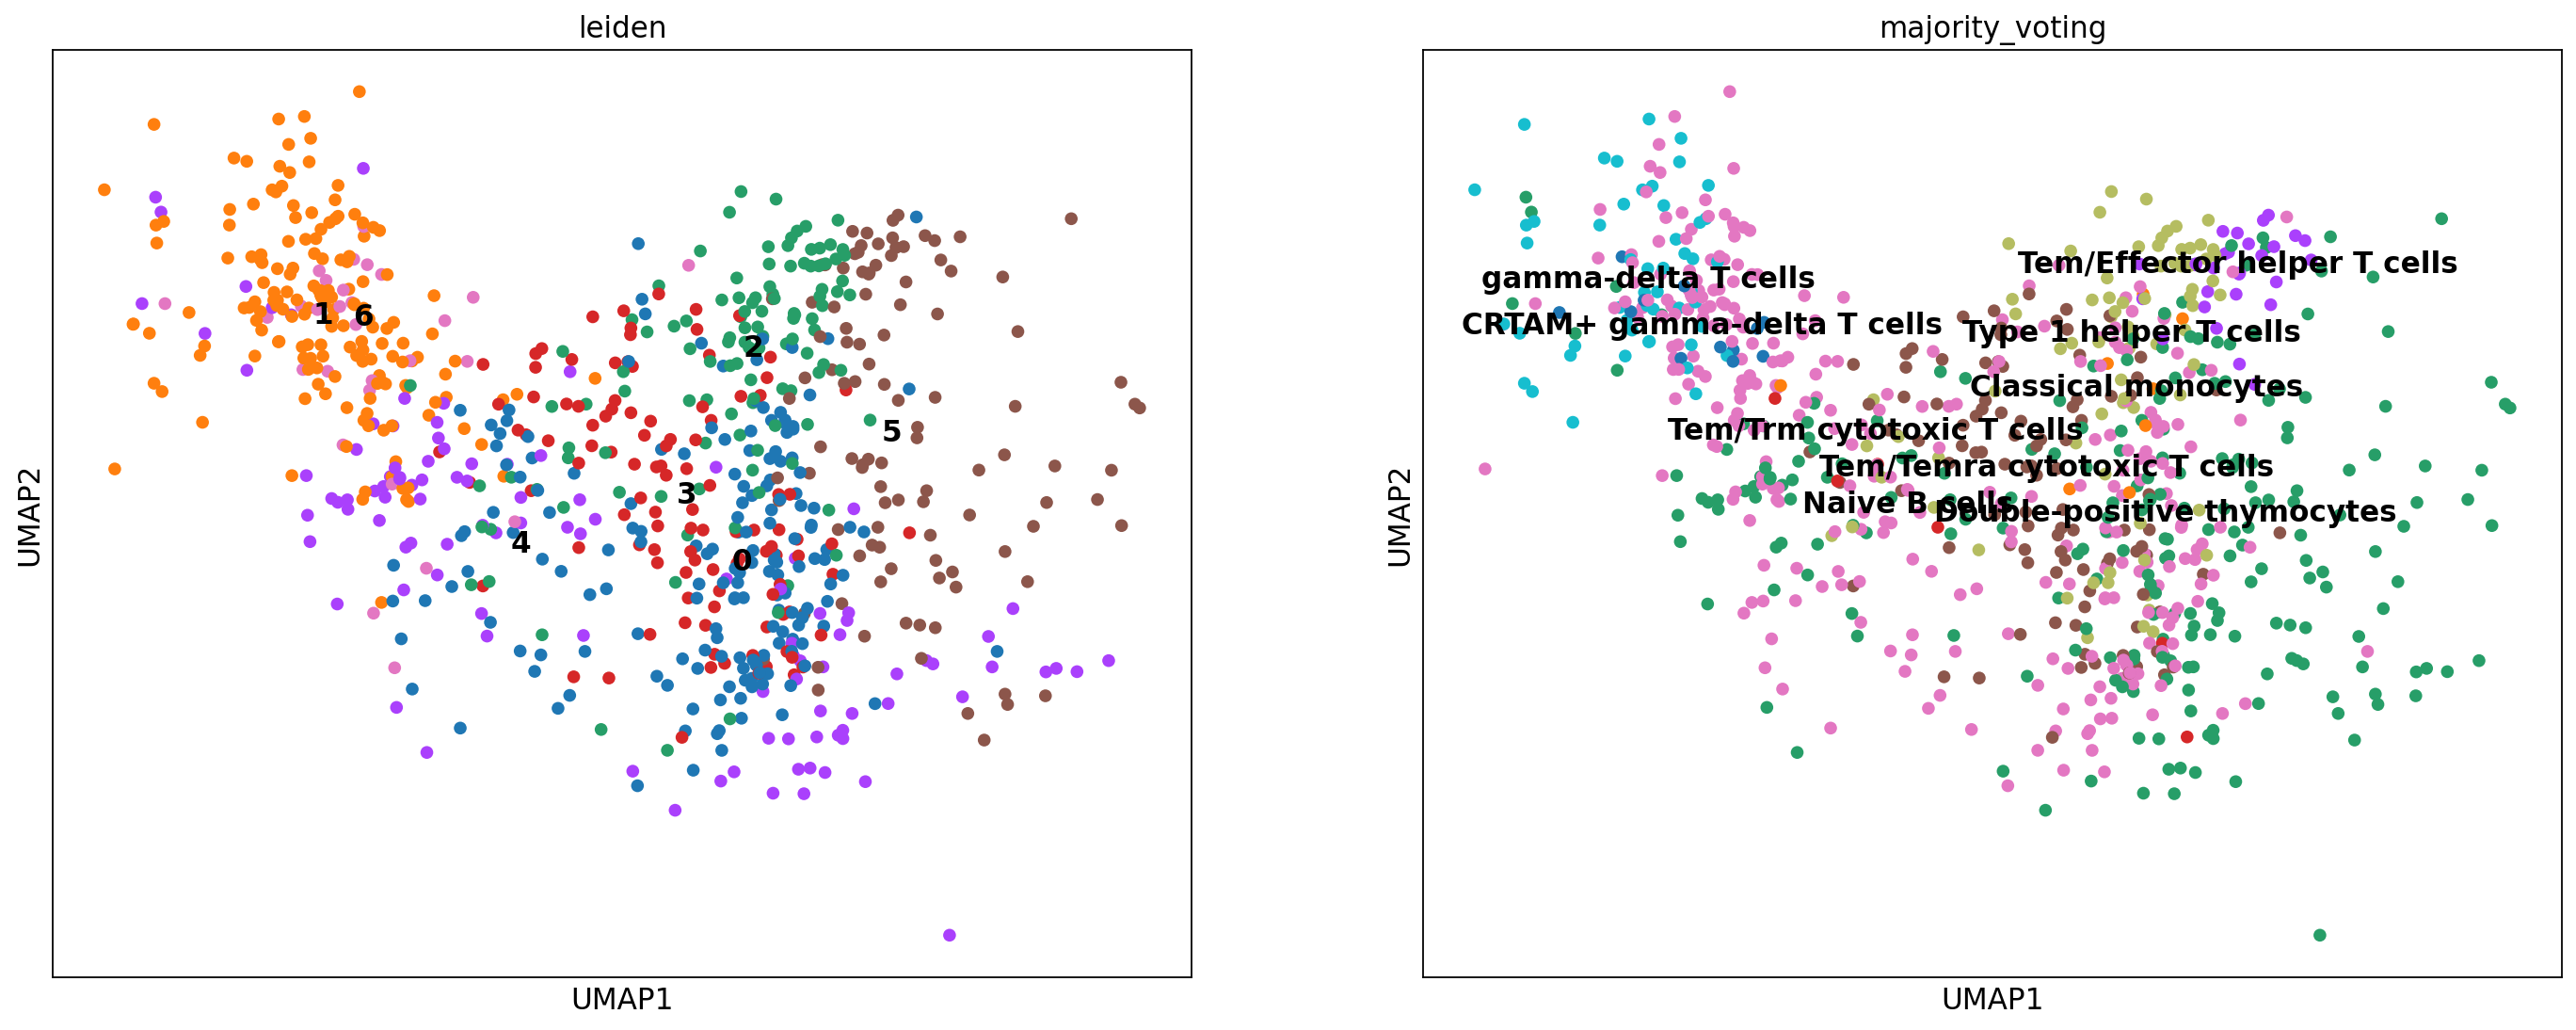

In [243]:
sc.pl.umap(adata, color=['leiden', 'majority_voting'], legend_loc='on data')

In [245]:
# crosstab as before
import pandas as pd
pd.crosstab(adata.obs['leiden'], adata.obs['majority_voting'])
#some heterogenous clusters, need to check again
# higher resolution maybe needed

majority_voting,CRTAM+ gamma-delta T cells,Classical monocytes,Double-positive thymocytes,Naive B cells,Tem/Effector helper T cells,Tem/Temra cytotoxic T cells,Tem/Trm cytotoxic T cells,Type 1 helper T cells,gamma-delta T cells
leiden,,,,,,,,,
0,0,0,40,0,0,0,109,22,0
1,12,0,1,0,0,0,100,1,50
2,0,8,3,0,4,4,44,53,0
3,0,0,10,0,0,96,3,0,0
4,0,0,95,6,0,0,6,0,0
5,0,0,79,0,24,0,3,0,0
6,0,0,0,0,0,0,29,0,0


In [4]:
#adata

In [2]:
#/home/rstudio/analysis/saved_objects
## export
#adata.write_h5ad('/home/rstudio/analysis/saved_objects/rna_2_celltypist_leiden.h5ad')

NameError: name 'adata' is not defined